# Divide-and-Conquer VQE on the 19-site Kagome lattice, with SU(2)-preserving junctions

**Goal.** Apply the divide-and-conquer strategy to the 19-site KAFH lattice of Task 1, but without breaking SU(2): where the paper stitches sub-circuits with junction $R_y(\theta)$ rotations, we use the Heisenberg / eSWAP gate of Task 1,
$U_H(\theta)=\exp\!\big(-i\theta\,(XX+YY+ZZ)/4\big)$, which commutes with $S^2_{\rm tot}$.
The protocol therefore conserves the total-spin sector at every stage by construction:

* **Step 1 (local VQE):** split the lattice into two subregions, optimize each ground
  state separately with the Task-1 HVA (`kagome_hva.HVASimulator`, L-BFGS-B + adjoint
  gradient), each with its own exact-diagonalization reference.
* **Step 2 (global VQE):** concatenate the two optimized sub-circuits with their
  parameters **frozen**, and optimize **only** new $U_H$ gates placed on the six bonds
  of the interface — the SU(2) analogue of the paper's "junction qubits".

**Metric discipline:**
fidelities are always projections onto the full degenerate ground manifold
(Task-1 Sec. 4.6c: the 19-site ground state is a doublet; single-eigenvector fidelities
are run-dependent); every optimization is repeated with *5 independent seeds* and
reported as mean ± std; parameter/gate counts and wall-clock costs are tracked per stage.

All new logic lives in [`kagome_dc.py`](kagome_dc.py) (documented like `kagome_hva.py`);
Task-1 modules are imported from `../1_Task/`. Heavy cells persist
their optima in `results/*.npz` and auto-load on re-run: the first full run takes
roughly **1.5–2.5 h** for §1–8 (the §9 follow-ups add up to ~3 h more if recomputed
from scratch); with `results/` populated a re-run takes minutes.

**Sections.** §1 partition · §2 exact references · §3 Step 1 (local VQEs) ·
§4 Step 2 (junction VQE: per-bond / shared / H_SEL) · §5 interface microscopy ·
§6 error attribution · §7 cost ledger · §8 discussion · §9 follow-ups (exact-local pipeline, prolongation, 26 sites).

In [32]:
# --- Environment: reuse ALL of Task 1, add only the divide-and-conquer layer ---
import sys, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

HERE = Path.cwd()
if not (HERE / "kagome_dc.py").exists():          # kernel started elsewhere
    HERE = Path("/home/tesla/Qintern2026/2_Task")
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import kagome_dc as dc     # Task-2 module (this folder); adds ../1_Task to sys.path itself
import kagome_hva as K     # Task-1 engine — imported, never copied

RESULTS, FIGURES = HERE / "results", HERE / "figures"
RESULTS.mkdir(exist_ok=True); FIGURES.mkdir(exist_ok=True)

SEEDS = (0, 1, 2, 3, 4)    # >= 5 independent seeds for every optimization in this task
C_R1, C_R2, C_IF, C_T1 = dc.COLOR_R1, dc.COLOR_R2, dc.COLOR_IFC, dc.COLOR_T1
print(f"kagome_dc : {dc.__file__}")
print(f"kagome_hva: {K.__file__}")

kagome_dc : /home/tesla/Qintern2026/2_Task/kagome_dc.py
kagome_hva: /home/tesla/Qintern2026/1_Task/kagome_hva.py


## 1. The partition

The 19-site lattice (two Kagome unit cells) is split into

* **subregion 1** = sites 0–10 (11 sites, **odd** → doublet target, $\langle S^2\rangle=0.75$),
* **subregion 2** = sites 11–18 (8 sites, **even** → singlet target, $\langle S^2\rangle=0$),
* 6 interface bonds that are *removed* in Step 1 and *reconnected* by junction gates in Step 2.

Why six bonds and not one, unlike the paper's simplest junction example: the two-cell
hexagram has corner-sharing triangles at both ends of the chain, so this cut splits
three of the ten triangles — $(0,1,17)$, $(1,2,11)$ and $(10,11,12)$. It behaves like
several simultaneous junction qubits; note $(1,2,11)$ and $(10,11,12)$ share site 11,
so the junctions are not independent of each other.

Two dimer-cover decisions forced by the cut (a cover may not cross it):
subregion 1 keeps 5 singlets and leaves its spinon on site 10 — at the interface
(sites 10–11–12 form a split triangle); subregion 2 gets a perfect 4-dimer cover
$(11,12),(13,14),(15,16),(17,18)$; it cannot reuse $(12,13),(14,15),(16,17)$ from the
Task-1 `dimers_19` because that would orphan sites 11 and 18, which share no bond inside
the subregion.

The check below validates the partition against the actual `edges_19` parsed from the
Task-1 notebook. It aborts with the exact difference if anything mismatches.

In [33]:
# Single source of truth: the Task-1 notebook's own edges_19 / dimers_19.
edges_19, dimers_19 = dc.load_task1_lattice()
dc.check_partition(edges_19)

print(f"\nsubregion 1: sites 0..10  ({len(dc.SUB1_SITES)} sites, ODD -> doublet, <S^2>=0.75)")
print(f"   {len(dc.SUB1_EDGES)} bonds; dimers {dc.SUB1_DIMERS} + spinon on site 10")
print(f"subregion 2: sites 11..18 ({len(dc.SUB2_SITES)} sites, EVEN -> singlet, <S^2>=0)")
print(f"   {len(dc.SUB2_EDGES)} bonds; perfect cover {dc.SUB2_DIMERS}")
print(f"interface  : {len(dc.INTERFACE_EDGES)} bonds {dc.INTERFACE_EDGES}")
print(f"junctions  : sites {dc.JUNCTION_SITES}  ((1,2,11) and (10,11,12) share site 11)")

partition check: 14 + 10 + 6 = 30 bonds == edges_19  ✓ (disjoint, exact set equality)

subregion 1: sites 0..10  (11 sites, ODD -> doublet, <S^2>=0.75)
   14 bonds; dimers [(0, 1), (2, 3), (4, 5), (6, 7), (8, 9)] + spinon on site 10
subregion 2: sites 11..18 (8 sites, EVEN -> singlet, <S^2>=0)
   10 bonds; perfect cover [(11, 12), (13, 14), (15, 16), (17, 18)]
interface  : 6 bonds [(10, 11), (10, 12), (1, 11), (2, 11), (0, 17), (1, 17)]
junctions  : sites [0, 1, 2, 10, 11, 12, 17]  ((1,2,11) and (10,11,12) share site 11)


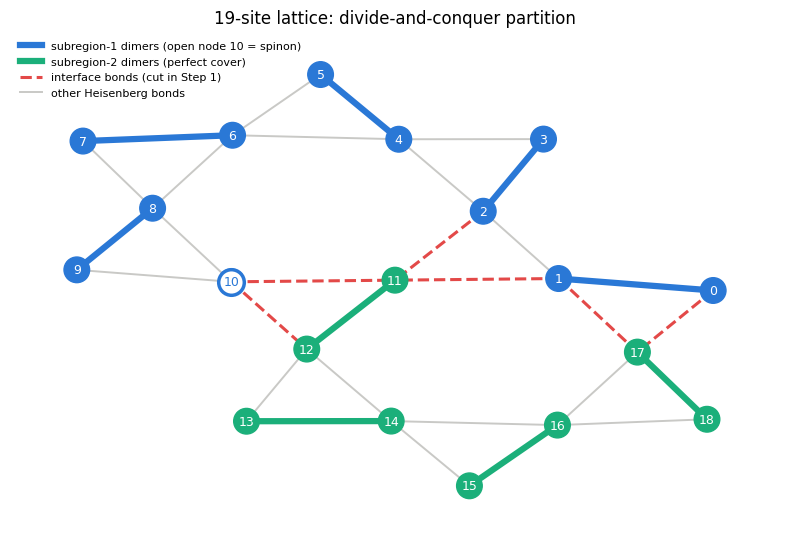

In [34]:
import networkx as nx
from matplotlib.lines import Line2D

G = nx.Graph([tuple(e) for e in edges_19])
pos = nx.kamada_kawai_layout(G)
IFC = {tuple(sorted(e)) for e in dc.INTERFACE_EDGES}
D1  = {tuple(sorted(d)) for d in dc.SUB1_DIMERS}
D2  = {tuple(sorted(d)) for d in dc.SUB2_DIMERS}

fig, ax = plt.subplots(figsize=(8, 5.5))
plain = [e for e in G.edges if tuple(sorted(e)) not in IFC | D1 | D2]
nx.draw_networkx_edges(G, pos, edgelist=plain, edge_color="#c9c9c6", width=1.4, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=[e for e in G.edges if tuple(sorted(e)) in D1],
                       edge_color=C_R1, width=4.5, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=[e for e in G.edges if tuple(sorted(e)) in D2],
                       edge_color=C_R2, width=4.5, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=[e for e in G.edges if tuple(sorted(e)) in IFC],
                       edge_color=C_IF, width=2.2, style="dashed", ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=[C_R1 if v <= 10 else C_R2 for v in G.nodes],
                       node_size=340, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=[10], node_color="white",
                       edgecolors=C_R1, linewidths=2.5, node_size=340, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_color="white", ax=ax)
nx.draw_networkx_labels(G, pos, labels={10: "10"}, font_size=9, font_color=C_R1, ax=ax)
ax.legend(handles=[
    Line2D([], [], color=C_R1, lw=4.5, label="subregion-1 dimers (open node 10 = spinon)"),
    Line2D([], [], color=C_R2, lw=4.5, label="subregion-2 dimers (perfect cover)"),
    Line2D([], [], color=C_IF, lw=2.2, ls="--", label="interface bonds (cut in Step 1)"),
    Line2D([], [], color="#c9c9c6", lw=1.4, label="other Heisenberg bonds"),
], loc="upper left", fontsize=8, frameon=False)
ax.set_title("19-site lattice: divide-and-conquer partition"); ax.axis("off")
fig.tight_layout(); fig.savefig(FIGURES / "partition_19.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Exact references with degenerate manifolds from the start

Four references, each with its ground manifold (not a single Lanczos vector):
the two isolated subregions, the *naive concatenation* (= the cut lattice: its exact
ground energy is $E_1+E_2$ and its manifold is the product doublet ⊗ singlet), and the
full 19-site lattice (already characterized in Task 1: doublet, $E_{19}=-29.146168$).

Physics to watch in the output: the subregion-2 perfect dimer cover should be its
exact ground state (Majumdar-Ghosh-like mechanism on this sawtooth-shaped strip:
each triangle carries one singlet and $\mathbf{S}_i\cdot(\mathbf{S}_j+\mathbf{S}_k)$
annihilates it) — so Step 1 for subregion 2 costs zero gates and zero parameters.

*The 19-site cell below is the one heavy ED of this notebook (sparse $2^{19}$ Lanczos,
$k=4$ to resolve the doublet):  ~2–3 GB of RAM on first run, then cached
in `results/ed19.npz`.*

In [35]:
# Local exact references (2^11 and 2^8: instant), degenerate-subspace metric built in.
sim1, sim2 = dc.make_subregion_sims()          # pure reuse of K.HVASimulator

E1, V1, w1 = dc.exact_ground_subspace(11, sim1.edges)
E2, V2, w2 = dc.exact_ground_subspace(8,  sim2.edges)
print(f"subregion 1: E1 = {E1:.6f}  degeneracy {V1.shape[1]} (doublet)  "
      f"<S^2> = {dc.s2_matrix_free(11, V1[:, 0]):.4f}  low spectrum {np.round(w1, 4)}")
print(f"subregion 2: E2 = {E2:.6f}  degeneracy {V2.shape[1]} (singlet)  "
      f"<S^2> = {dc.s2_matrix_free(8, V2[:, 0]):.4f}  low spectrum {np.round(w2, 4)}")

# Majumdar-Ghosh check: is subregion 2's dimer product already its exact ground state?
f2_dimer = dc.subspace_fidelity(sim2.psi0.reshape(-1), V2)
e2_dimer = float(np.real(np.vdot(sim2.psi0.reshape(-1),
                                 sim2.H_sparse @ sim2.psi0.reshape(-1))))
print(f"\nsubregion-2 dimer product: E = {e2_dimer:.6f}, "
      f"fidelity to exact ground = {f2_dimer:.10f}")

E_naive = E1 + E2      # exact ground energy of the CUT lattice (no interface bonds)
print(f"\nnaive concatenation (exact): E1+E2 = {E_naive:.6f}  "
      f"(doublet x singlet -> degeneracy {V1.shape[1] * V2.shape[1]}, <S^2> = 0.75)")

subregion 1: E1 = -16.000000  degeneracy 2 (doublet)  <S^2> = 0.7500  low spectrum [-16.     -16.     -15.5502 -15.5458]
subregion 2: E2 = -12.000000  degeneracy 1 (singlet)  <S^2> = 0.0000  low spectrum [-12.     -10.7255 -10.7255 -10.7255]

subregion-2 dimer product: E = -12.000000, fidelity to exact ground = 1.0000000000

naive concatenation (exact): E1+E2 = -28.000000  (doublet x singlet -> degeneracy 2, <S^2> = 0.75)


In [36]:
# --- Full 19-site exact reference ---
ED19_FILE = RESULTS / "ed19.npz"
if ED19_FILE.exists():
    _d = np.load(ED19_FILE)
    E19, evals19, V19 = float(_d["E0"]), _d["evals"], _d["V"]
    print(f"loaded {ED19_FILE.name}")
else:
    t0 = time.perf_counter()
    E19, V19, evals19 = dc.exact_ground_subspace(19, [tuple(e) for e in edges_19],
                                                 k_probe=4)
    np.savez(ED19_FILE, E0=E19, evals=evals19, V=V19)
    print(f"ED(19 sites) in {time.perf_counter() - t0:.0f} s -> cached {ED19_FILE.name}")

print(f"E19 = {E19:.6f}   low spectrum {np.round(evals19, 6)}")
print(f"ground degeneracy: {V19.shape[1]} (doublet)   "
      f"<S^2> = {dc.s2_matrix_free(19, V19[:, 0]):.4f}")
psi19_up = dc.project_sz(V19, 19, +0.5)[:, 0]   # Sz=+1/2 component (the HVA sector)

loaded ed19.npz
E19 = -29.146168   low spectrum [-29.146168 -29.146168 -29.005514 -29.005514]
ground degeneracy: 2 (doublet)   <S^2> = 0.7500


In [37]:
bd = E19 - E_naive
print(f"{'reference':<32s} {'E_exact':>12s}  {'ground manifold':>16s}  {'<S^2>':>6s}")
for name, e, degs, s2t in [
        ("subregion 1 (11 sites)",     E1,      "doublet (2)",              0.75),
        ("subregion 2 (8 sites)",      E2,      "singlet (1)",              0.00),
        ("naive concat (cut lattice)", E_naive, "2 x 1 = 2",                0.75),
        ("full 19-site lattice",       E19,     f"doublet ({V19.shape[1]})", 0.75)]:
    print(f"{name:<32s} {e:>12.6f}  {degs:>16s}  {s2t:>6.2f}")
print(f"\nboundary energy = E19 - (E1+E2) = {bd:.6f}   "
      f"({abs(bd)/abs(E19)*100:.3f}% of |E19|)  <-  what Step 2 must recover")

reference                             E_exact   ground manifold   <S^2>
subregion 1 (11 sites)             -16.000000       doublet (2)    0.75
subregion 2 (8 sites)              -12.000000       singlet (1)    0.00
naive concat (cut lattice)         -28.000000         2 x 1 = 2    0.75
full 19-site lattice               -29.146168       doublet (2)    0.75

boundary energy = E19 - (E1+E2) = -1.146168   (3.932% of |E19|)  <-  what Step 2 must recover


## 3. Step 1: local VQEs (5 seeds each)

Each subregion is optimized in isolation with the unchanged Task-1 machinery:
`K.HVASimulator` on the subregion's own bonds/dimers (local qubit indices),
full per-bond HVA, L-BFGS-B with the validated adjoint gradient, layer-by-layer warm
start + random restarts. New for Task 2: every sweep is repeated with **5 seeds**, and
the fidelity column is the projection onto the subregion's degenerate ground manifold
(the doublet for subregion 1).

*Expected cost: subregion 1 ($2^{11}$, depths 1–4, 5 seeds); subregion 2 is
essentially free. Both cells cache to `results/`.*

In [38]:
# --- Step 1a: subregion 1 (11 qubits, doublet target) ---
SUB1_FILE = RESULTS / "sub1_sweeps.npz"
if SUB1_FILE.exists():
    sw1 = dc.load_sweeps(SUB1_FILE); print(f"loaded {SUB1_FILE.name} ({len(sw1)} seeds)")
else:
    t0 = time.perf_counter()
    sw1 = dc.run_local_multiseed(sim1, E1, V1, seeds=SEEDS, max_reps=4, maxiter=300)
    dc.save_sweeps(sw1, SUB1_FILE)
    print(f"total {time.perf_counter() - t0:.0f} s -> saved {SUB1_FILE.name}")

def local_report(sweeps, title):
    aggs = {k: dc.aggregate_sweeps(sweeps, k) for k in ("err_pct", "s2", "fidelity")}
    print(f"\n{title}")
    print(f"{'reps':>4s} {'params':>6s} | {'err %  mean ± std':>19s} {'best':>9s} | "
          f"{'<S^2>':>7s} | {'F(manifold) mean ± std':>22s}")
    for reps in sorted(aggs["err_pct"]):
        npar = next(r["n_params"] for r in sweeps[0] if r["reps"] == reps)
        e, s, f = (aggs[k][reps] for k in ("err_pct", "s2", "fidelity"))
        print(f"{reps:>4d} {npar:>6d} | {e[0]:>10.4f} ± {e[1]:<6.4f} {e[2]:>9.4f} | "
              f"{s[0]:>7.4f} | {f[0]:>11.4f} ± {f[1]:<8.4f}")
    return aggs

aggs1 = local_report(sw1, "subregion 1 (spinon @ site 10):")

loaded sub1_sweeps.npz (5 seeds)

subregion 1 (spinon @ site 10):
reps params |   err %  mean ± std      best |   <S^2> | F(manifold) mean ± std
   0      0 |     6.2500 ± 0.0000    6.2500 |  0.7500 |      0.0035 ± 0.0000  
   1     14 |     2.9257 ± 0.0151    2.9174 |  0.7500 |      0.0062 ± 0.0004  
   2     28 |     2.8254 ± 0.0021    2.8237 |  0.7500 |      0.0094 ± 0.0008  
   3     42 |     2.8116 ± 0.0028    2.8063 |  0.7500 |      0.0136 ± 0.0016  
   4     56 |     2.8023 ± 0.0049    2.7959 |  0.7500 |      0.0224 ± 0.0057  


In [39]:
# --- Step 1b: subregion 2 (8 qubits, singlet target) ---
SUB2_FILE = RESULTS / "sub2_sweeps.npz"
if SUB2_FILE.exists():
    sw2 = dc.load_sweeps(SUB2_FILE); print(f"loaded {SUB2_FILE.name} ({len(sw2)} seeds)")
else:
    sw2 = dc.run_local_multiseed(sim2, E2, V2, seeds=SEEDS, max_reps=2, maxiter=200)
    dc.save_sweeps(sw2, SUB2_FILE)

aggs2 = local_report(sw2, "subregion 2 (perfect dimer cover):")
print("\n-> the reps=0 row IS the frozen subregion-2 circuit: the Majumdar-Ghosh-like")
print("   cover is exact, so Step 1 for this region costs 0 gates and 0 parameters.")

loaded sub2_sweeps.npz (5 seeds)

subregion 2 (perfect dimer cover):
reps params |   err %  mean ± std      best |   <S^2> | F(manifold) mean ± std
   0      0 |     0.0000 ± 0.0000    0.0000 |  0.0000 |      1.0000 ± 0.0000  
   1     10 |     0.0000 ± 0.0000    0.0000 | -0.0000 |      1.0000 ± 0.0000  
   2     20 |     0.0000 ± 0.0000    0.0000 | -0.0000 |      1.0000 ± 0.0000  

-> the reps=0 row IS the frozen subregion-2 circuit: the Majumdar-Ghosh-like
   cover is exact, so Step 1 for this region costs 0 gates and 0 parameters.


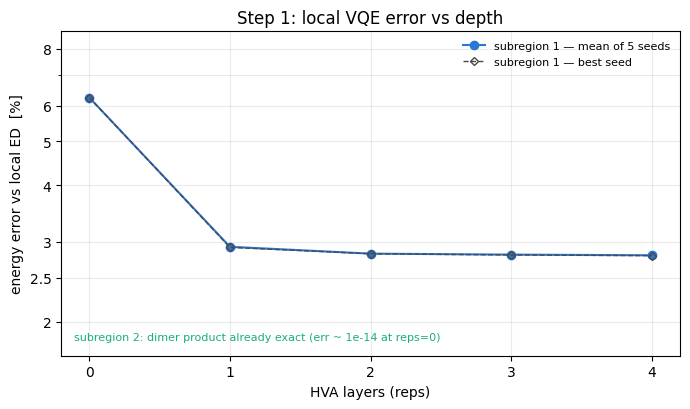

In [40]:
# Error vs depth for the local VQEs (mean ± std over the 5 seeds).
agg_e = dc.aggregate_sweeps(sw1, "err_pct")
reps_ax = sorted(agg_e)
m  = np.array([agg_e[r][0] for r in reps_ax])
sd = np.array([agg_e[r][1] for r in reps_ax])
bt = np.array([agg_e[r][2] for r in reps_ax])

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.fill_between(reps_ax, np.clip(m - sd, 1e-6, None), m + sd,
                color=C_R1, alpha=0.18, lw=0)
ax.plot(reps_ax, m, "o-", color=C_R1, label="subregion 1 — mean of 5 seeds")
ax.plot(reps_ax, bt, "D--", color="#4a4a48", mfc="none", ms=4, lw=1,
        label="subregion 1 — best seed")
ax.set_yscale("log")
ax.set_ylim(m.min() * 0.6, m.max() * 1.4)          # headroom for the annotation
ax.set_yticks([t for t in (1, 1.5, 2, 2.5, 3, 4, 5, 6, 8, 10, 15, 20)
               if m.min() * 0.6 < t < m.max() * 1.4])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
ax.yaxis.set_minor_formatter(plt.NullFormatter())
ax.set_xticks(reps_ax)
ax.set_xlabel("HVA layers (reps)")
ax.set_ylabel("energy error vs local ED  [%]")
ax.text(0.02, 0.05, "subregion 2: dimer product already exact (err ~ 1e-14 at reps=0)",
        transform=ax.transAxes, fontsize=8, color=C_R2)
ax.grid(alpha=0.25, which="both")
ax.legend(frameon=False, fontsize=8)
ax.set_title("Step 1: local VQE error vs depth")
fig.tight_layout(); fig.savefig(FIGURES / "local_err_vs_depth.png", dpi=150,
                                bbox_inches="tight")
plt.show()

### 3.1 Design control: where should the spinon live?

The mandated cover leaves the unpaired spin on site 10 — physically appealing (the
spinon sits exactly where region 1 must later resonate with region 2), but it is a
*choice*, and local optimization difficulty depends on it. As a control we run the same
subregion with the cover shifted by one bond, so the spinon sits on site 0 (the free
end of the chain, maximally far from the cut). The pipeline continues with the mandated
cover; the control only *quantifies* how much of the final error budget is attributable
to local-VQE suboptimality rather than to interface expressivity (picked up again in §6).

In [41]:
SPIN_FILE = RESULTS / "spinon_control.npz"
alt_dimers = [(1, 2), (3, 4), (5, 6), (7, 8), (9, 10)]     # spinon on site 0
sim1_alt = K.HVASimulator(11, sim1.edges, alt_dimers)
if SPIN_FILE.exists():
    sw1_alt = dc.load_sweeps(SPIN_FILE); print(f"loaded {SPIN_FILE.name}")
else:
    sw1_alt = dc.run_local_multiseed(sim1_alt, E1, V1, seeds=SEEDS, max_reps=2,
                                     maxiter=300, verbose=False)
    dc.save_sweeps(sw1_alt, SPIN_FILE)

for label, sw in (("spinon @ site 10 (interface end — used in the pipeline)", sw1),
                  ("spinon @ site 0  (free end — control)",                   sw1_alt)):
    a = dc.aggregate_sweeps(sw, "err_pct")
    row = "   ".join(f"reps {r}: {a[r][0]:9.4f} ± {a[r][1]:<8.4f}%"
                     for r in sorted(a) if 1 <= r <= 2)
    print(f"{label:<55s} {row}")

loaded spinon_control.npz
spinon @ site 10 (interface end — used in the pipeline) reps 1:    2.9257 ± 0.0151  %   reps 2:    2.8254 ± 0.0021  %
spinon @ site 0  (free end — control)                   reps 1:    0.0000 ± 0.0000  %   reps 2:    0.0000 ± 0.0000  %


### 3.2 The frozen sub-circuits

Subregion 1 is frozen at its best depth-4 seed (56 parameters, now fixed forever);
subregion 2's frozen circuit is just its four singlet preparations. Circuits are drawn
with `output='mpl'`, using the same color code as every figure
in this notebook: **blue = subregion 1, green = subregion 2, red = interface**.

frozen subregion-1 circuit: reps=4, 56 params, best-seed err 2.7959% (seed index 2)


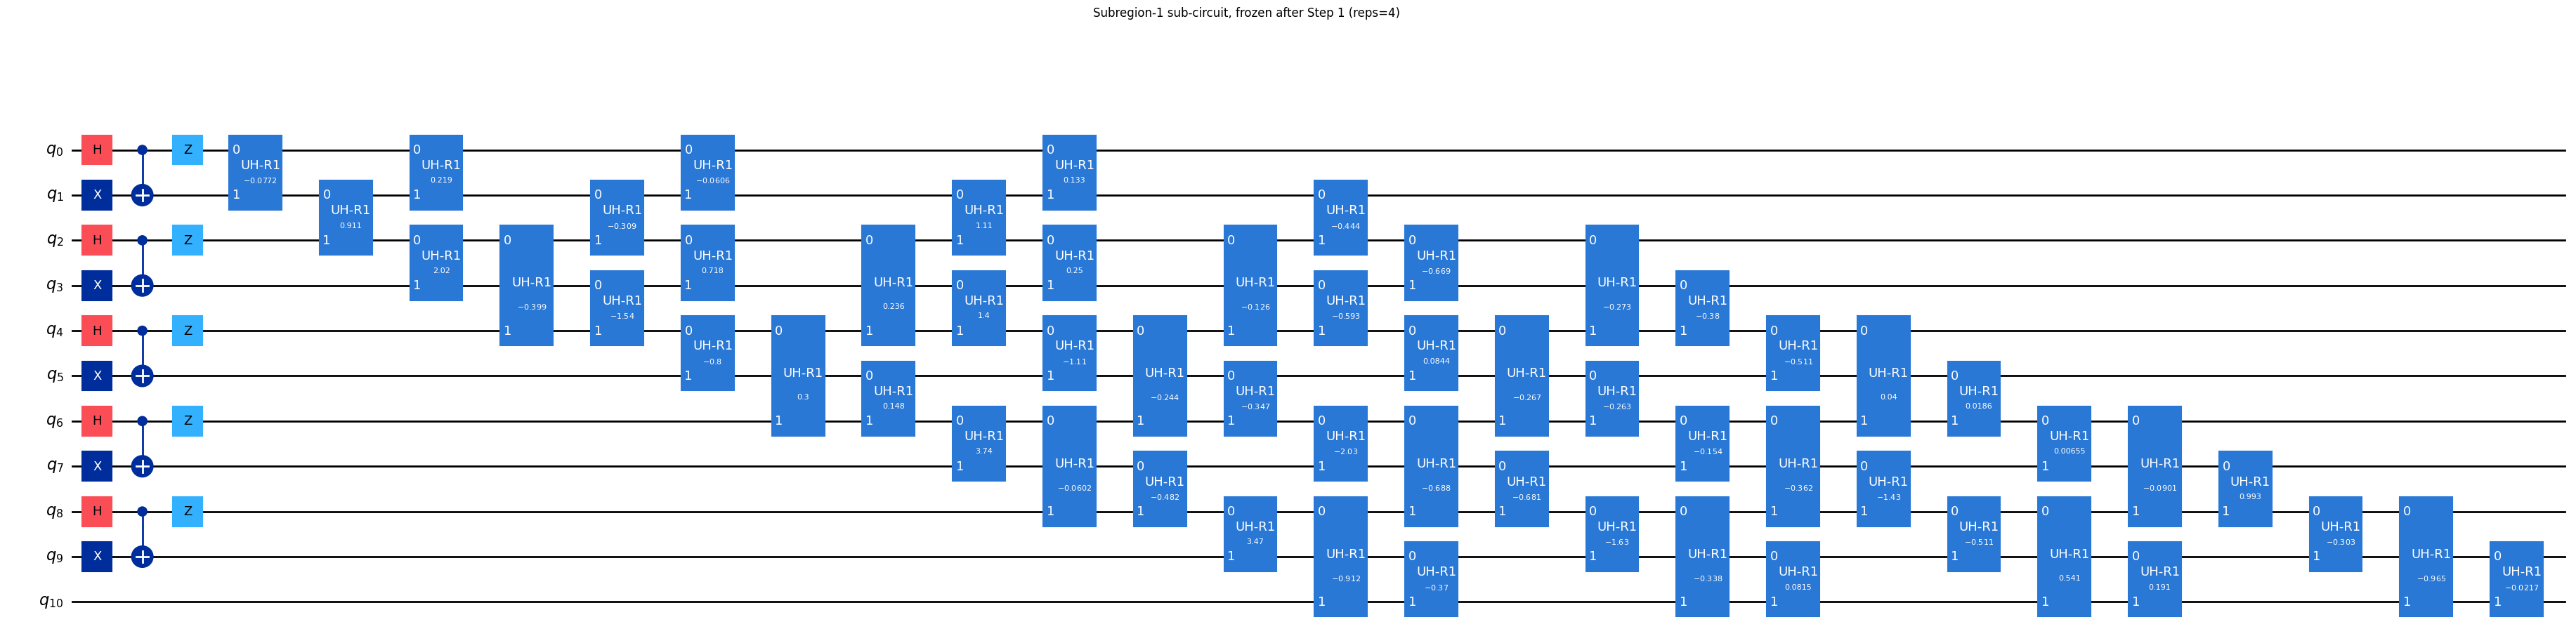

In [42]:
REPS1 = 4                        # freeze depth for subregion 1 (see curve above)
x1_frozen, seed1_best = dc.best_of_sweeps(sw1, REPS1)
err1_frozen = dc.aggregate_sweeps(sw1, "err_pct")[REPS1][2]
print(f"frozen subregion-1 circuit: reps={REPS1}, {x1_frozen.size} params, "
      f"best-seed err {err1_frozen:.4f}% (seed index {seed1_best})")

fig = dc.build_region_drawing(1, x1_frozen, REPS1).draw(output="mpl",
                                                        style=dc.MPL_STYLE, fold=-1)
fig.suptitle(f"Subregion-1 sub-circuit, frozen after Step 1 (reps={REPS1})", y=1.04)
fig.savefig(FIGURES / "circuit_sub1.png", dpi=130, bbox_inches="tight")
fig

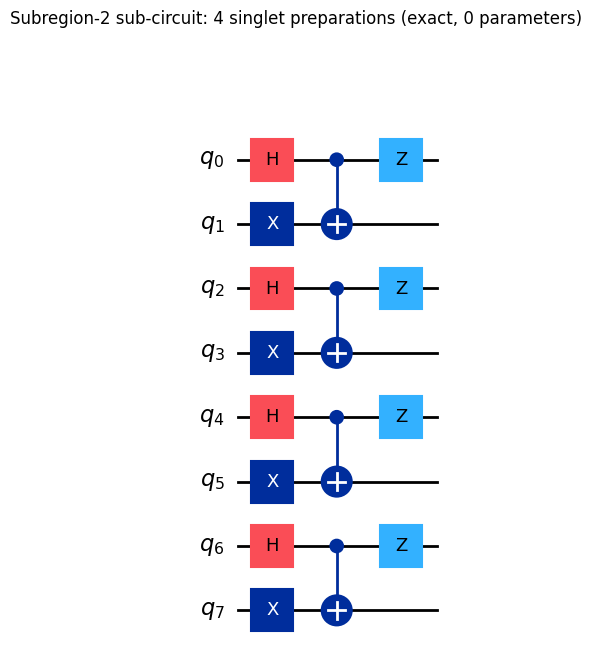

In [43]:
# Subregion 2 needs NO variational layers: its frozen circuit is the bare cover.
fig = dc.build_region_drawing(2, [], 0).draw(output="mpl", style=dc.MPL_STYLE)
fig.suptitle("Subregion-2 sub-circuit: 4 singlet preparations (exact, 0 parameters)",
             y=1.02)
fig.savefig(FIGURES / "circuit_sub2.png", dpi=130, bbox_inches="tight")
fig

In [44]:
# Resource ledger of Step 1 (CNOT counting: U_H -> 3 CNOTs, singlet prep -> 1 CNOT).
rows = [dc.resources(REPS1 * len(dc.SUB1_EDGES), len(dc.SUB1_DIMERS),
                     REPS1 * len(dc.SUB1_EDGES), f"subregion 1 alone (reps={REPS1})"),
        dc.resources(0, len(dc.SUB2_DIMERS), 0, "subregion 2 alone (exact cover)")]
rows.append(dict(label="naive concatenation (frozen, no junctions)",
                 params=0, u_h=rows[0]["u_h"],
                 cnot=rows[0]["cnot"] + rows[1]["cnot"],
                 dimers=rows[0]["dimers"] + rows[1]["dimers"]))
rows.append(dict(label="Task-1 monolithic hybrid (reference)",
                 params=180, u_h=180, cnot=3 * 180 + 9, dimers=9))
print(f"{'stage':<44s} {'free params*':>12s} {'U_H':>5s} {'CNOT':>6s}")
for r in rows:
    print(f"{r['label']:<44s} {r['params']:>12d} {r['u_h']:>5d} {r['cnot']:>6d}")
print("* parameters optimized SIMULTANEOUSLY at that stage")

stage                                        free params*   U_H   CNOT
subregion 1 alone (reps=4)                             56    56    173
subregion 2 alone (exact cover)                         0     0      4
naive concatenation (frozen, no junctions)              0    56    177
Task-1 monolithic hybrid (reference)                  180   180    549
* parameters optimized SIMULTANEOUSLY at that stage


## 4. Step 2: the junction VQE (global VQE over the interface only)

The two frozen sub-circuits are concatenated into one 19-qubit state
$|\psi_{\rm frozen}\rangle$ (absorbed into the initial state of the recombination
engine — the 56 frozen parameters are never touched again), and we optimize only
new $U_H$ gates on the 6 interface bonds. `dc.RecombinationVQE` is matrix-free:
$H|\psi\rangle$ is applied bond-by-bond with the Task-1 two-qubit kernel, so no
$2^{19}$-dimensional sparse operator is ever built (Task-1's `sim19` held ~1.7 GB of
sparse matrices; here the working set is a few statevectors).

**The stationarity no-go (measured below).** If both frozen states were *exact* local
eigenstates, then for any interface generator $A$,
$\partial_\theta\langle e^{iA\theta}He^{-iA\theta}\rangle|_{\theta=0}
= -i\langle[A,H]\rangle = 0$: the naive concatenation is a stationary point of the
junction optimization. Warm-starting from $\theta=0$ is therefore useless; every seed
starts from a *random* interface configuration, and the frozen state itself is kept as
a fallback candidate so no run can end *above* it.

Three configurations, all with 5 seeds, all metrics evaluated on the full $H$:

| config | parameters | optimized against | tests |
|---|---|---|---|
| **A** | one $\theta$ per bond per layer ($6\cdot$reps) | $H_{\rm full}$ | the direct Fig.-4 analogue (paper) |
| **B** | one shared $\theta$ per layer (reps) | $H_{\rm full}$ | is a symmetric junction enough? |
| **C** | one $\theta$ per bond per layer | $H_{\rm SEL}$ | the paper's reduced junction Hamiltonian |

$H_{\rm SEL}$ follows the advisor's construction (notebook cells 22–23,
`junct_meas_lst`/`meas_lst_sel`): for each junction site, keep the bonds among
{junction} ∪ {its immediate neighbours}, the same reduction that takes the paper's
549-term 103-qubit Hamiltonian down to its junction neighbourhood. Here it keeps
21 of the 30 bonds (63 of 90 Pauli terms).

**Predictions to test** — P1: $\|\nabla E\|_{\theta=0}$ is tiny (near-stationary start);
P2: config B stays at the frozen energy (one shared angle preserves too much of the
product structure); P3: config A escapes only at depth ≥ 2–3 and recovers a large part
of the 3.9% boundary gap; P4: config C tracks config A at lower cost per iteration.

In [45]:
# --- The frozen concatenated state (Step-1 output; interface = identity) ---
psiF = dc.frozen_state(sim1, x1_frozen, REPS1, sim2, [], 0)
rec = dc.RecombinationVQE(psiF, edges_full=edges_19)

eF, errF = rec.energy(psiF), None
errF = abs(eF - E19) / abs(E19) * 100
print(f"E_frozen = {eF:.6f}   err vs E19 = {errF:.3f}%   "
      f"(bound with EXACT locals: {abs(E_naive - E19)/abs(E19)*100:.3f}%)")
print(f"<S^2>_frozen = {rec.s2(psiF):.6f}   (doublet x singlet)")
print(f"F(frozen -> 19q doublet manifold)      = {dc.subspace_fidelity(psiF, V19):.4f}")
Vn = np.column_stack([dc.embed_product(V1[:, c], V2[:, 0]) for c in range(V1.shape[1])])
print(f"F(frozen -> naive-concat exact manifold) = {dc.subspace_fidelity(psiF, Vn):.4f}"
      f"   (pure Step-1 quality)")

# P1 — the (near-)stationarity of the start, measured:
for reps_probe in (1, 3):
    _, gn = rec.gradient_at_zero(reps=reps_probe)
    print(f"|grad E| at theta=0 (reps={reps_probe}): {gn:.3e}")

print(f"\nH_SEL (advisor's cells 22-23 analogue): {len(rec.bonds_sel)} bonds "
      f"= {3*len(rec.bonds_sel)} Pauli terms   (full H: {len(edges_19)} bonds "
      f"= {3*len(edges_19)} terms)")
print(f"  {rec.bonds_sel}")

E_frozen = -27.552648   err vs E19 = 5.467%   (bound with EXACT locals: 3.932%)
<S^2>_frozen = 0.750000   (doublet x singlet)
F(frozen -> 19q doublet manifold)      = 0.0185
F(frozen -> naive-concat exact manifold) = 0.0215   (pure Step-1 quality)
|grad E| at theta=0 (reps=1): 1.533e-15
|grad E| at theta=0 (reps=3): 2.655e-15

H_SEL (advisor's cells 22-23 analogue): 21 bonds = 63 Pauli terms   (full H: 30 bonds = 90 terms)
  [(0, 1), (0, 17), (1, 2), (1, 11), (1, 17), (2, 3), (2, 4), (2, 11), (3, 4), (8, 9), (8, 10), (9, 10), (10, 11), (10, 12), (11, 12), (12, 13), (12, 14), (13, 14), (16, 17), (16, 18), (17, 18)]


In [46]:
# --- config A: per-bond junction VQE vs H_full ---
PB_FILE = RESULTS / "dnc19_perbond.npz"
runs_pb = dc.load_runs(PB_FILE) if PB_FILE.exists() else []
for reps in (1, 2, 3, 4):
    if any(r["reps"] == reps for r in runs_pb):
        continue
    print(f"-- per-bond, H_full, reps={reps} ({len(dc.INTERFACE_EDGES)*reps} params) --")
    runs_pb += rec.optimize(reps, e_ref=E19, per_bond=True, seeds=SEEDS,
                            maxiter=120, V_ref=V19)
    dc.save_runs(runs_pb, PB_FILE)            # incremental: safe to interrupt

def grid_report(runs, label):
    print(f"\n{label}")
    print(f"{'reps':>4s} {'params':>6s} | {'err %  mean ± std':>19s} {'best':>8s} | "
          f"{'<S^2>':>7s} | {'F(doublet) mean':>15s} | {'s/seed':>6s} {'iters':>6s}")
    for reps in sorted({r["reps"] for r in runs}):
        rr = [r for r in runs if r["reps"] == reps]
        st = dc.summarize_runs(rr)
        print(f"{reps:>4d} {rr[0]['n_params']:>6d} | {st['err_pct'][0]:>10.3f} ± "
              f"{st['err_pct'][1]:<6.3f} {min(r['err_pct'] for r in rr):>8.3f} | "
              f"{st['s2'][0]:>7.4f} | {st['fidelity'][0]:>15.4f} | "
              f"{st['time_s'][0]:>6.0f} {st['nit'][0]:>6.0f}")

grid_report(runs_pb, "config A: per-bond junction gates, optimized vs H_full")


config A: per-bond junction gates, optimized vs H_full
reps params |   err %  mean ± std     best |   <S^2> | F(doublet) mean | s/seed  iters
   1      6 |      5.467 ± 0.000     5.467 |  0.7500 |          0.0185 |      9     17
   2     12 |      4.897 ± 0.698     4.041 |  0.7500 |          0.0212 |     39     47
   3     18 |      3.864 ± 0.148     3.700 |  0.7500 |          0.0323 |    109    118
   4     24 |      3.656 ± 0.090     3.559 |  0.7500 |          0.0347 |    117    120


In [47]:
# --- config B: ONE shared theta per layer vs H_full ---
SH_FILE = RESULTS / "dnc19_shared.npz"
runs_sh = dc.load_runs(SH_FILE) if SH_FILE.exists() else []
for reps in (1, 2, 3, 4):
    if any(r["reps"] == reps for r in runs_sh):
        continue
    print(f"-- shared theta, H_full, reps={reps} ({reps} param{'s'*(reps>1)}) --")
    runs_sh += rec.optimize(reps, e_ref=E19, per_bond=False, seeds=SEEDS,
                            maxiter=120, V_ref=V19)
    dc.save_runs(runs_sh, SH_FILE)

grid_report(runs_sh, "config B: shared junction angle per layer, vs H_full")


config B: shared junction angle per layer, vs H_full
reps params |   err %  mean ± std     best |   <S^2> | F(doublet) mean | s/seed  iters
   1      1 |      5.467 ± 0.000     5.467 |  0.7500 |          0.0185 |      3      3
   2      2 |      5.467 ± 0.000     5.467 |  0.7500 |          0.0185 |     11     12
   3      3 |      5.467 ± 0.000     5.467 |  0.7500 |          0.0185 |     14     14
   4      4 |      5.467 ± 0.000     5.467 |  0.7500 |          0.0185 |     17     16


In [48]:
# --- config C: per-bond junction VQE vs H_SEL  ---
# Optimizes <H_SEL> (21 bonds); the err/fidelity columns are ALWAYS vs the full H.
SEL_FILE = RESULTS / "dnc19_hsel.npz"
runs_sel = dc.load_runs(SEL_FILE) if SEL_FILE.exists() else []
for reps in (1, 2, 3, 4):
    if any(r["reps"] == reps for r in runs_sel):
        continue
    print(f"-- per-bond, H_SEL, reps={reps} ({len(dc.INTERFACE_EDGES)*reps} params) --")
    runs_sel += rec.optimize(reps, e_ref=E19, per_bond=True, use_sel=True,
                             seeds=SEEDS, maxiter=120, V_ref=V19)
    dc.save_runs(runs_sel, SEL_FILE)

grid_report(runs_sel, "config C: per-bond junction gates, optimized vs H_SEL "
                      "(metrics vs H_full)")


config C: per-bond junction gates, optimized vs H_SEL (metrics vs H_full)
reps params |   err %  mean ± std     best |   <S^2> | F(doublet) mean | s/seed  iters
   1      6 |      5.467 ± 0.000     5.467 |  0.7500 |          0.0185 |      8     17
   2     12 |      4.445 ± 0.560     4.041 |  0.7500 |          0.0233 |     44     72
   3     18 |      3.864 ± 0.148     3.700 |  0.7500 |          0.0322 |     84    119
   4     24 |      3.656 ± 0.091     3.556 |  0.7500 |          0.0348 |    107    120


In [49]:
# --- Unified Step-2 ledger, against the Task-1 monolithic references ---
print(f"{'stage / config':<40s} {'params*':>7s} {'err % (mean ± std | best)':>26s} "
      f"{'<S^2>':>7s} {'F':>6s}")
print(f"{'frozen concatenation (Step 1 only)':<40s} {0:>7d} "
      f"{errF:>18.3f}   |  {errF:>5.3f} {0.75:>7.4f} "
      f"{dc.subspace_fidelity(psiF, V19):>6.3f}")
for fam, runs in (("A per-bond H_full", runs_pb), ("B shared  H_full", runs_sh),
                  ("C per-bond H_SEL", runs_sel)):
    for reps in sorted({r["reps"] for r in runs}):
        rr = [r for r in runs if r["reps"] == reps]
        st = dc.summarize_runs(rr)
        print(f"{fam + f', reps={reps}':<40s} {rr[0]['n_params']:>7d} "
              f"{st['err_pct'][0]:>13.3f} ± {st['err_pct'][1]:<5.3f} | "
              f"{min(r['err_pct'] for r in rr):>6.3f} {st['s2'][0]:>7.4f} "
              f"{st['fidelity'][0]:>6.3f}")
print(f"{'-'*88}")
for label, p, e in (("Task-1 symmetric HVA", 30, 3.98),
                    ("Task-1 full HVA", 120, 0.80),
                    ("Task-1 hybrid sym->full", 180, 0.52)):
    print(f"{label + ' (monolithic)':<40s} {p:>7d} {e:>18.2f}   |  {e:>5.2f} "
          f"{0.75:>7.4f} {'—':>6s}")
print("* parameters optimized simultaneously (junction VQE: interface angles only;")
print("  Task-1 rows optimize every parameter of the whole lattice at once)")

stage / config                           params*  err % (mean ± std | best)   <S^2>      F
frozen concatenation (Step 1 only)             0              5.467   |  5.467  0.7500  0.018
A per-bond H_full, reps=1                      6         5.467 ± 0.000 |  5.467  0.7500  0.018
A per-bond H_full, reps=2                     12         4.897 ± 0.698 |  4.041  0.7500  0.021
A per-bond H_full, reps=3                     18         3.864 ± 0.148 |  3.700  0.7500  0.032
A per-bond H_full, reps=4                     24         3.656 ± 0.090 |  3.559  0.7500  0.035
B shared  H_full, reps=1                       1         5.467 ± 0.000 |  5.467  0.7500  0.018
B shared  H_full, reps=2                       2         5.467 ± 0.000 |  5.467  0.7500  0.018
B shared  H_full, reps=3                       3         5.467 ± 0.000 |  5.467  0.7500  0.018
B shared  H_full, reps=4                       4         5.467 ± 0.000 |  5.467  0.7500  0.018
C per-bond H_SEL, reps=1                       6       

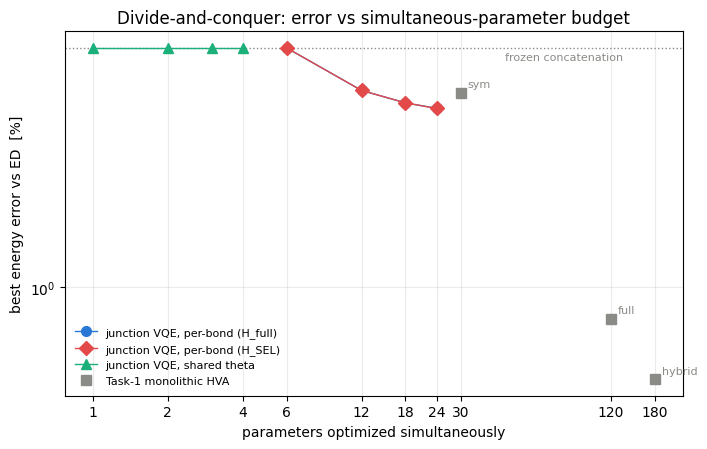

In [50]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.axhline(errF, color=C_T1, lw=1, ls=":")
ax.text(45, errF * 0.97, "frozen concatenation", fontsize=8, color=C_T1,
        va="top")

for label, runs, c, mk in (
        ("junction VQE, per-bond (H_full)", runs_pb,  C_R1, "o"),
        ("junction VQE, per-bond (H_SEL)",  runs_sel, C_IF, "D"),
        ("junction VQE, shared theta",      runs_sh,  C_R2, "^")):
    xs = sorted({r["reps"] for r in runs})
    px = [next(r["n_params"] for r in runs if r["reps"] == x) for x in xs]
    py = [min(r["err_pct"] for r in runs if r["reps"] == x) for x in xs]
    ax.plot(px, py, mk, ls="-", lw=1, color=c, ms=7, label=label)

t1 = [(30, 3.98, "sym"), (120, 0.80, "full"), (180, 0.52, "hybrid")]
ax.plot([p for p, _, _ in t1], [e for _, e, _ in t1], "s", color=C_T1, ms=7,
        ls="none", label="Task-1 monolithic HVA")
for p, e, s in t1:
    ax.annotate(s, (p, e), textcoords="offset points", xytext=(5, 4),
                fontsize=8, color=C_T1)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xticks([1, 2, 4, 6, 12, 18, 24, 30, 120, 180])
ax.xaxis.set_major_formatter(plt.ScalarFormatter()); ax.minorticks_off()
ax.set_xlabel("parameters optimized simultaneously")
ax.set_ylabel("best energy error vs ED  [%]")
ax.grid(alpha=0.25, which="both")
ax.legend(frameon=False, fontsize=8, loc="lower left")
ax.set_title("Divide-and-conquer: error vs simultaneous-parameter budget")
fig.tight_layout(); fig.savefig(FIGURES / "dnc_summary.png", dpi=150,
                                bbox_inches="tight")
plt.show()

## 5. Interface microscopy

Global energy alone cannot tell whether the junction gates are doing the *right* thing;
Task-1 Sec. 4.6 taught us to look bond-by-bond. Here we focus on the interface
specifically: (a) the bond-energy map; the frozen state carries *exactly zero*
energy on the 6 cut bonds (every interface site pairs a maximally-mixed reduced state
on at least one side), so whatever negative bond energy appears there is resonance
created by the junction gates; (b) the entanglement entropy across every cut
$S(k)$ — the region cut $k=11$ separates the two subregions, where the frozen state has
exactly 0 bits and the exact ground state has a finite value the junctions must rebuild;
(c) the recombined circuit drawing (frozen = blue/green, new = red).

best junction-VQE state: config A, reps=4 (24 params), err 3.559%, seed 0


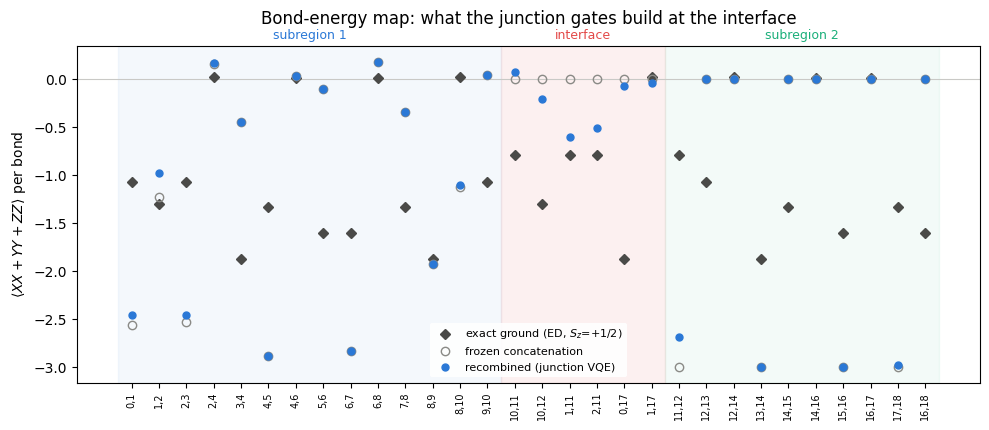


 interface bond       ED   frozen      DnC
       (10, 11)   -0.793    0.000    0.078
       (10, 12)   -1.296   -0.000   -0.206
        (1, 11)   -0.793    0.000   -0.605
        (2, 11)   -0.793   -0.000   -0.509
        (0, 17)   -1.878    0.000   -0.077
        (1, 17)    0.023    0.000   -0.039


In [51]:
best_pb = min(runs_pb, key=lambda r: r["err_pct"])
sched_b, _ = rec.schedule(best_pb["reps"], per_bond=True)
sv_best = rec.statevector(best_pb["x"], sched_b)
print(f"best junction-VQE state: config A, reps={best_pb['reps']} "
      f"({best_pb['n_params']} params), err {best_pb['err_pct']:.3f}%, "
      f"seed {best_pb['seed']}")

bmap = lambda sv: {tuple(sorted(k)): v for k, v in rec.bond_energies(sv).items()}
m_ed, m_fr, m_dc = bmap(psi19_up), bmap(psiF), bmap(sv_best)
order = ([tuple(e) for e in dc.SUB1_EDGES] + [tuple(e) for e in dc.INTERFACE_EDGES]
         + [tuple(e) for e in dc.SUB2_EDGES])
xs = np.arange(len(order))

fig, ax = plt.subplots(figsize=(10, 4.4))
ax.axvspan(-0.5, 13.5, color=C_R1, alpha=0.05)
ax.axvspan(13.5, 19.5, color=C_IF, alpha=0.08)
ax.axvspan(19.5, 29.5, color=C_R2, alpha=0.05)
ax.axhline(0, color="#c9c9c6", lw=0.8)
ax.plot(xs, [m_ed[e] for e in order], "D", color="#4a4a48", ms=5,
        label="exact ground (ED, $S_z$=+1/2)")
ax.plot(xs, [m_fr[e] for e in order], "o", mfc="none", color=C_T1, ms=6,
        label="frozen concatenation")
ax.plot(xs, [m_dc[e] for e in order], "o", color=C_R1, ms=5,
        label="recombined (junction VQE)")
ax.set_xticks(xs); ax.set_xticklabels([f"{i},{j}" for i, j in order],
                                      rotation=90, fontsize=7)
import matplotlib.transforms as mtr
tr = mtr.blended_transform_factory(ax.transData, ax.transAxes)
for x, lab, col in ((6.5, "subregion 1", C_R1), (16.5, "interface", C_IF),
                    (24.5, "subregion 2", C_R2)):
    ax.text(x, 1.02, lab, transform=tr, color=col, fontsize=9, ha="center")
ax.set_ylabel(r"$\langle XX+YY+ZZ\rangle$ per bond")
ax.legend(fontsize=8, loc="lower center", framealpha=0.9, edgecolor="none")
ax.set_title("Bond-energy map: what the junction gates build at the interface",
             pad=16)
fig.tight_layout(); fig.savefig(FIGURES / "interface_bonds.png", dpi=150,
                                bbox_inches="tight")
plt.show()

print(f"\n{'interface bond':>15s} {'ED':>8s} {'frozen':>8s} {'DnC':>8s}")
for e in [tuple(e) for e in dc.INTERFACE_EDGES]:
    print(f"{str(e):>15s} {m_ed[e]:>8.3f} {m_fr[e]:>8.3f} {m_dc[e]:>8.3f}")

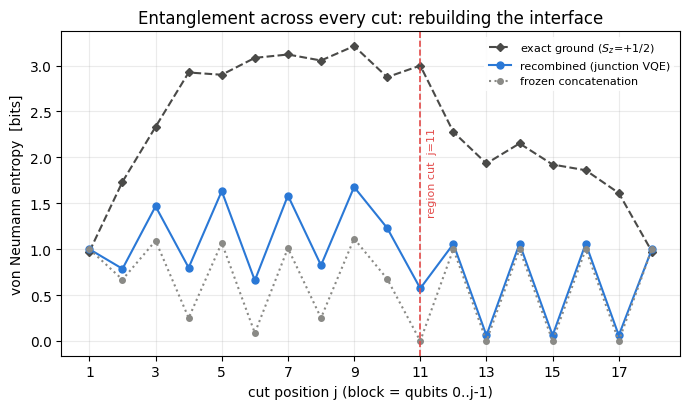

S(k=11):  frozen = 0.0000 bits (product state -> exactly 0),  junction VQE = 0.5729,  ED = 3.0000
-> the junction gates rebuilt 19% of the exact interface entanglement


In [52]:
# Entanglement entropy across every cut (Task-1 reuse). CONVENTION FIX:
# K.entanglement_entropy_cuts blocks the leading TENSOR axes, i.e. the top
# qubits {19-k..18}; reversing the list converts it to blocks of PHYSICAL
# qubits {0..j-1}, so the region cut (block = subregion 1) sits at j=11.
S_fr = K.entanglement_entropy_cuts(19, psiF)[::-1]
S_dc = K.entanglement_entropy_cuts(19, sv_best)[::-1]
S_ed = K.entanglement_entropy_cuts(19, psi19_up)[::-1]
assert S_fr[10] < 1e-9, "frozen state must be a product across the region cut j=11"
ks = np.arange(1, 19)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(ks, S_ed, "D--", color="#4a4a48", ms=4, label="exact ground ($S_z$=+1/2)")
ax.plot(ks, S_dc, "o-",  color=C_R1, ms=5, label="recombined (junction VQE)")
ax.plot(ks, S_fr, "o:",  color=C_T1, ms=4, label="frozen concatenation")
ax.axvline(11, color=C_IF, lw=1.2, ls="--")
ax.text(11.2, 1.35, "region cut  j=11", color=C_IF, fontsize=8, rotation=90,
        va="bottom")
ax.set_xticks(ks[::2]); ax.set_xlabel("cut position j (block = qubits 0..j-1)")
ax.set_ylabel("von Neumann entropy  [bits]")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="upper right", framealpha=0.9, edgecolor="none")
ax.set_title("Entanglement across every cut: rebuilding the interface")
fig.tight_layout(); fig.savefig(FIGURES / "interface_entropy.png", dpi=150,
                                bbox_inches="tight")
plt.show()

print(f"S(k=11):  frozen = {S_fr[10]:.4f} bits (product state -> exactly 0),  "
      f"junction VQE = {S_dc[10]:.4f},  ED = {S_ed[10]:.4f}")
print(f"-> the junction gates rebuilt {S_dc[10]/S_ed[10]*100:.0f}% of the exact "
      f"interface entanglement")

full detail -> figures/circuit_recombined_full.png (supplementary)


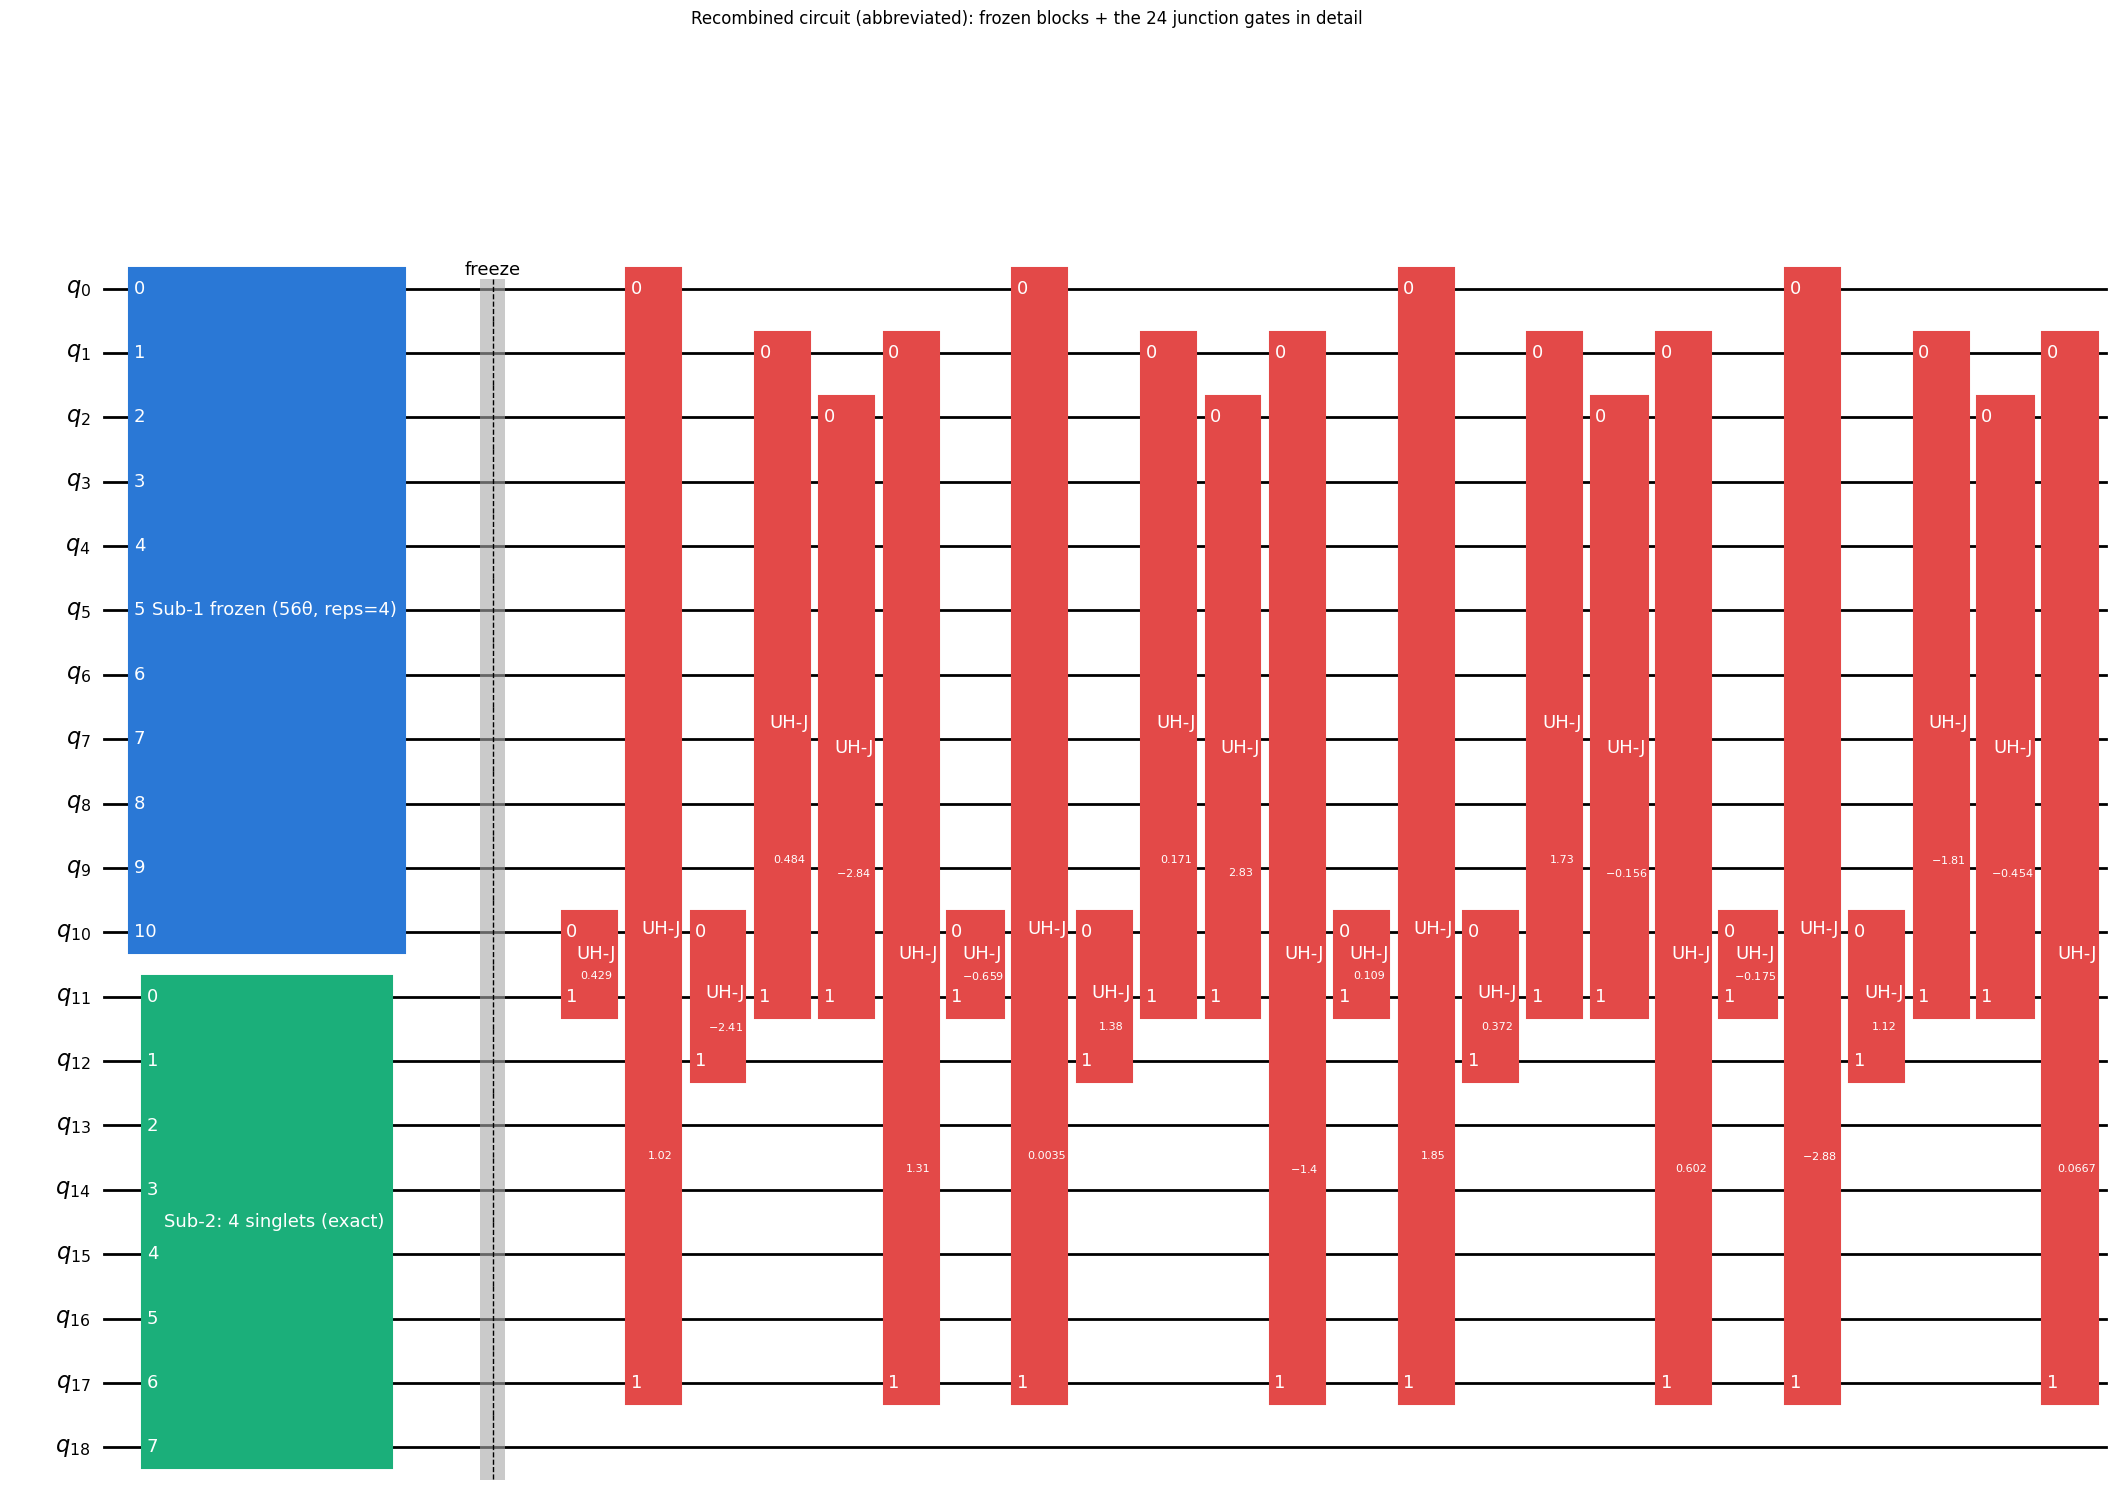

In [53]:
# Recombined circuit. MAIN figure = the ABBREVIATED view: the
# frozen sub-circuits collapse into one labeled block each and 
# only the Step-2 junction gates (red) appear
# in detail. The fully expanded drawing (80 U_H / 249 CNOTs, several screens
# tall) goes to disk as supplementary material, not inline.
figf = dc.build_recombined_drawing(x1_frozen, REPS1, [], 0, best_pb["x"],
                                   best_pb["reps"]).draw(
    output="mpl", style=dc.MPL_STYLE, fold=42)
figf.savefig(FIGURES / "circuit_recombined_full.png", dpi=110,
             bbox_inches="tight")
plt.close(figf)
print("full detail -> figures/circuit_recombined_full.png (supplementary)")

qc_cmp = dc.build_recombined_compact(
    best_pb["x"], best_pb["reps"],
    label1=f"Sub-1 frozen ({x1_frozen.size}\u03b8, reps={REPS1})",
    label2="Sub-2: 4 singlets (exact)")
fig = qc_cmp.draw(output="mpl", style=dc.MPL_STYLE, fold=-1)
fig.suptitle(f"Recombined circuit (abbreviated): frozen blocks + the "
             f"{best_pb['n_params']} junction gates in detail", y=1.02)
fig.savefig(FIGURES / "circuit_recombined.png", dpi=150, bbox_inches="tight")
fig

## 6. Error attribution: interface expressivity vs local suboptimality

The recombined state misses the benchmark by some residual. Two distinct culprits:

1. **Interface expressivity** — even with *perfect* local states, a few layers of $U_H$
   on 6 bonds may simply be unable to represent the entangled ground state;
2. **Local suboptimality** — subregion 1's VQE state is itself imperfect
   (and §3.1 showed the spinon placement affects how imperfect).

The control below isolates (1): rebuild the frozen state from the exact local
ground states (the $S_z=+1/2$ doublet component of subregion 1 ⊗ the singlet of
subregion 2, matching the HVA's spin sector) and rerun the same junction VQE. Its
residual error is a pure expressivity floor; the gap between it and the VQE-frozen
result of §4 measures (2). This start is also *exactly* stationary, so it doubles as
the cleanest measurement of prediction P1.

In [54]:
XF_FILE = RESULTS / "dnc19_exact_frozen.npz"
psiF_x = dc.embed_product(dc.project_sz(V1, 11, +0.5)[:, 0], V2[:, 0])
rec_x = dc.RecombinationVQE(psiF_x, edges_full=edges_19)
eFx = rec_x.energy(psiF_x)
_, gnx = rec_x.gradient_at_zero(reps=1)
print(f"exact-frozen start: E = {eFx:.6f} (= E1+E2)   "
      f"err {abs(eFx - E19)/abs(E19)*100:.3f}%   |grad| at theta=0 = {gnx:.2e}")

REPS_CTRL = best_pb["reps"]                      # same depth as the best config-A run
if XF_FILE.exists():
    runs_x = dc.load_runs(XF_FILE); print(f"loaded {XF_FILE.name}")
else:
    runs_x = rec_x.optimize(REPS_CTRL, e_ref=E19, per_bond=True, seeds=SEEDS,
                            maxiter=120, V_ref=V19)
    dc.save_runs(runs_x, XF_FILE)
grid_report(runs_x, f"exact-frozen control (per-bond, H_full, reps={REPS_CTRL})")

best_x = min(runs_x, key=lambda r: r["err_pct"])
print(f"\nattribution at reps={REPS_CTRL}:")
print(f"  expressivity floor (exact locals) : {best_x['err_pct']:.3f}%")
print(f"  VQE-frozen best (Sec. 4)          : {best_pb['err_pct']:.3f}%")
print(f"  -> local-VQE suboptimality adds   : "
      f"{best_pb['err_pct'] - best_x['err_pct']:+.3f} pts")

exact-frozen start: E = -28.000000 (= E1+E2)   err 3.932%   |grad| at theta=0 = 1.02e-15
loaded dnc19_exact_frozen.npz

exact-frozen control (per-bond, H_full, reps=4)
reps params |   err %  mean ± std     best |   <S^2> | F(doublet) mean | s/seed  iters
   4     24 |      1.980 ± 0.246     1.815 |  0.7500 |          0.2167 |    116    120

attribution at reps=4:
  expressivity floor (exact locals) : 1.815%
  VQE-frozen best (Sec. 4)          : 3.559%
  -> local-VQE suboptimality adds   : +1.744 pts


## 7. Cost ledger: the divide-and-conquer trade

The point of the strategy (paper Sec. 4.2.2): never optimize the whole parameter vector
at once. The table below shows what each stage actually cost on this machine,
against the Task-1 monolithic runs. Note the seeds: DnC numbers below are
totals over 5 seeds.

In [55]:
tot = lambda runs: sum(r["time_s"] for r in runs)
t_best_cfg = sum(r["time_s"] for r in runs_pb if r["reps"] == best_pb["reps"])
rows = [
    ("Step 1a: subregion-1 sweep (5 seeds, reps 1-4)", 56,
     sum(sw[0]["time_s"] for sw in sw1)),
    ("Step 1b: subregion-2 sweep (exact at reps=0)", 0,
     sum(sw[0]["time_s"] for sw in sw2)),
    ("Step 2 A: per-bond H_full grid (5 seeds x 4 depths)", 24, tot(runs_pb)),
    ("Step 2 B: shared-theta grid", 4, tot(runs_sh)),
    ("Step 2 C: per-bond H_SEL grid", 24, tot(runs_sel)),
    ("control: exact-frozen junction VQE", 6 * REPS_CTRL, tot(runs_x)),
]
print(f"{'stage':<52s} {'max simult. params':>18s} {'wall time':>10s}")
for label, p, t in rows:
    print(f"{label:<52s} {p:>18d} {t/60:>8.1f} m")

n_uh_rec = REPS1 * len(dc.SUB1_EDGES) + len(dc.INTERFACE_EDGES) * best_pb["reps"]
res_rec = dc.resources(n_uh_rec, 9, best_pb["n_params"])
print(f"\nrecombined circuit at the best point: {res_rec['u_h']} U_H gates, "
      f"{res_rec['cnot']} CNOTs, {best_pb['n_params']} junction params "
      f"(+56 frozen local params)")
print(f"minimal DnC pipeline (Step 1 + config A reps={best_pb['reps']}): "
      f"{(rows[0][2] + rows[1][2] + t_best_cfg)/60:.1f} min over 5 seeds "
      f"-> err {best_pb['err_pct']:.3f}%")
print("Task-1 monolithic:  120 params ~36 min -> 0.80%   |   "
      "180 params ~38 min -> 0.52%  (single runs, ALL params at once)")

stage                                                max simult. params  wall time
Step 1a: subregion-1 sweep (5 seeds, reps 1-4)                       56      1.1 m
Step 1b: subregion-2 sweep (exact at reps=0)                          0      0.0 m
Step 2 A: per-bond H_full grid (5 seeds x 4 depths)                  24     22.9 m
Step 2 B: shared-theta grid                                           4      3.7 m
Step 2 C: per-bond H_SEL grid                                        24     20.2 m
control: exact-frozen junction VQE                                   24      9.7 m

recombined circuit at the best point: 80 U_H gates, 249 CNOTs, 24 junction params (+56 frozen local params)
minimal DnC pipeline (Step 1 + config A reps=4): 10.9 min over 5 seeds -> err 3.559%
Task-1 monolithic:  120 params ~36 min -> 0.80%   |   180 params ~38 min -> 0.52%  (single runs, ALL params at once)


## 8. Discussion

The cell below assembles the verdict from the persisted data (it reflects whatever
is currently in `results/`), answering the two questions posed for this task; the
closing text interprets them.

In [56]:
# ---- Auto-verdict from the saved runs ----
all_runs = runs_pb + runs_sh + runs_sel + runs_x
s2_dev = max(abs(r["s2"] - 0.75) for r in all_runs)
best_overall = min(runs_pb + runs_sel, key=lambda r: r["err_pct"])
fam = "H_SEL" if best_overall["use_sel"] else "H_full"

print("Q1 — Does divide-and-conquer with Heisenberg junction gates approach the")
print("     benchmark with fewer SIMULTANEOUSLY optimized parameters, preserving S^2?")
print(f"   frozen -> recombined error: {errF:.3f}% -> {best_overall['err_pct']:.3f}% "
      f"({fam}, reps={best_overall['reps']}, {best_overall['n_params']} junction params)")
print(f"   boundary gap recovered: "
      f"{100*(errF - best_overall['err_pct'])/errF:.0f}% of the frozen deficit")
print(f"   pipeline max simultaneous params: {max(56, best_overall['n_params'])} "
      f"(the subregion-1 local VQE) vs 120/180 monolithic (Task 1)")
print(f"   Task-1 ladder: 3.98% @ 30p | 0.80% @ 120p | 0.52% @ 180p (monolithic)")
print(f"   <S^2> deviation from 0.75 over ALL {len(all_runs)} saved runs: {s2_dev:.1e}")

print("\nQ2 — Where is the residual error lost?")
best_x2 = min(runs_x, key=lambda r: r["err_pct"])
print(f"   interface expressivity floor (exact locals, reps={best_x2['reps']}): "
      f"{best_x2['err_pct']:.3f}%")
print(f"   local-VQE suboptimality contribution: "
      f"{best_pb['err_pct'] - best_x2['err_pct']:+.3f} pts "
      f"(subregion-1 local err {err1_frozen:.3f}% with spinon@10; cf. control §3.1)")
if runs_sh:
    print(f"   shared-theta junctions (config B) best: "
          f"{min(r['err_pct'] for r in runs_sh):.3f}%  "
          f"(vs frozen {errF:.3f}% — how rigid is one angle?)")
print("\nH_SEL vs H_full at equal depth (best seed, time = mean per seed):")
for reps in sorted({r["reps"] for r in runs_pb} & {r["reps"] for r in runs_sel}):
    ea = min(r["err_pct"] for r in runs_pb if r["reps"] == reps)
    ec = min(r["err_pct"] for r in runs_sel if r["reps"] == reps)
    ta = np.mean([r["time_s"] for r in runs_pb if r["reps"] == reps])
    tc = np.mean([r["time_s"] for r in runs_sel if r["reps"] == reps])
    print(f"   reps={reps}: H_full {ea:6.3f}% ({ta:4.0f}s)   "
          f"H_SEL {ec:6.3f}% ({tc:4.0f}s)")

Q1 — Does divide-and-conquer with Heisenberg junction gates approach the
     benchmark with fewer SIMULTANEOUSLY optimized parameters, preserving S^2?
   frozen -> recombined error: 5.467% -> 3.556% (H_SEL, reps=4, 24 junction params)
   boundary gap recovered: 35% of the frozen deficit
   pipeline max simultaneous params: 56 (the subregion-1 local VQE) vs 120/180 monolithic (Task 1)
   Task-1 ladder: 3.98% @ 30p | 0.80% @ 120p | 0.52% @ 180p (monolithic)
   <S^2> deviation from 0.75 over ALL 65 saved runs: 3.4e-14

Q2 — Where is the residual error lost?
   interface expressivity floor (exact locals, reps=4): 1.815%
   local-VQE suboptimality contribution: +1.744 pts (subregion-1 local err 2.796% with spinon@10; cf. control §3.1)
   shared-theta junctions (config B) best: 5.467%  (vs frozen 5.467% — how rigid is one angle?)

H_SEL vs H_full at equal depth (best seed, time = mean per seed):
   reps=1: H_full  5.467% (   9s)   H_SEL  5.467% (   8s)
   reps=2: H_full  4.041% (  39s)   H_

### Reading the verdict

**On Q1.** The junction VQE never optimizes more than a few dozen parameters at once
(6·reps interface angles; the largest single optimization anywhere in the pipeline is
the 56-parameter *local* sweep of subregion 1 — on 2¹¹ amplitudes, not 2¹⁹), and
$\langle S^2\rangle=0.75$ holds to machine precision in every saved run, because
every gate in the pipeline (dimer preparations, local HVA layers, junction gates)
commutes with $S^2$. The honest comparison is not raw error (a monolithic HVA with 3–7×
more simultaneous parameters *should* win) but error per simultaneously-optimized
parameter and per optimizer-second, which is what the summary figure of §4 and the
ledger of §7 report. The structural point survives regardless of the exact numbers:
Step 1 costs are local (small registers), and Step 2's cost is set by the interface
size, not the system size.

**On Q2.** Three independent handles separate the two loss channels: the exact-frozen
control (§6) gives the pure interface-expressivity floor at fixed depth; the difference
to the VQE-frozen pipeline gives the local-suboptimality contribution (with the spinon
control of §3.1 showing how much of *that* is a dimer-cover choice, and if that
control cover is locally exact, the expressivity floor is *practically reachable*:
freeze the spinon@0 sub-circuit instead and the pipeline starts from exact locals); and config B shows how much expressivity is lost by collapsing the six junction angles into one. The stationarity measurement (P1) explains *why* this landscape is treacherous: the natural warm start is a critical point, so junction VQE needs the multi-seed random-restart protocol used throughout, a lesson worth carrying to the hardware version, where each restart costs real shots.

**Scaling outlook.** The same partition logic extends to the k-cell star chains of `kagome_mps.py` (26, 33, 40, 47 sites). Two regimes: (i) **26 sites**: local VQEs stay trivial (≤ 19 qubits each), and because
`RecombinationVQE` applies H bond-by-bond with blocked low-memory kernels, the junction
VQE fits this machine (executed in §9.3), the first true test of "cost set by interface, not system". (ii) **47 sites**: statevectors are out; Task-1 Sec. 4.5 showed Aer-MPS provides no adjoint gradient and gradient-free optimizers stall exactly on the flat landscapes that Step 2 produces, so this regime needs a tensor-network backend with autodiff (quimb) or hardware. Divide-and-conquer is precisely the strategy that makes those runs shallow enough to attempt.

---
*Module: [`kagome_dc.py`](kagome_dc.py) · optima persisted in `results/*.npz` · figures
in `figures/` · Task-1 machinery imported from [`../1_Task/kagome_hva.py`](../1_Task/kagome_hva.py).*

## 9. Follow-ups: closing the local gap, converging the junctions, one lattice up

Three extensions that §8's verdict makes obvious.

* **9.1 (a) The pipeline §6 said we should have run.** The exact-frozen control proved the
  interface can reach ≈1.8%, and §3.1 proved the spinon@0 dimer cover makes subregion 1
  locally exact, so freeze *that* sub-circuit (14 params, reps=1) and rerun the
  junction VQE. This is a deployable circuit, not an ED vector.
* **9.2 (b) Prolongation.** Every reps≥3 run of §4/§6 stopped at the 120-iteration cap
  (`nit=120`), not at convergence. `RecombinationVQE.refine` restarts L-BFGS from the
  *saved optima* with a +400-iteration budget (config A and the control, at reps=4).
* **9.3 (c) 26 sites.** `kagome_star_chain(3)` nests `chain(2)` as a strict prefix, so
  subregion 1 of the 26-site lattice is the 19-site system and its Step 1 is
  already paid for: the Task-1 hybrid optimum (0.52%, 180 params) is relabeled onto the
  chain by a graph isomorphism + qubit permutation of the statevector (energy preserved
  to 1e-8, verified). Subregion 2 is 7 new sites (exact by ED); the interface is only
  4 bonds on the two shared tip sites.

In [57]:
# --- (a) junction VQE on the locally EXACT pipeline (spinon@0 frozen) ----------
ALT_FILE = RESULTS / "dnc19_alt.npz"
x1_alt, _ = dc.best_of_sweeps(sw1_alt, 1)          # reps=1, 14 params, exact (§3.1)
psiF_alt = dc.frozen_state(sim1_alt, x1_alt, 1, sim2, [], 0)
rec_alt = dc.RecombinationVQE(psiF_alt, edges_full=edges_19)
eF_alt = rec_alt.energy(psiF_alt)
print(f"frozen(spinon@0): E = {eF_alt:.6f}   err {abs(eF_alt-E19)/abs(E19)*100:.4f}% "
      f"  (spinon@10 froze at {errF:.3f}%)")

if ALT_FILE.exists():
    runs_alt = dc.load_runs(ALT_FILE); print(f"loaded {ALT_FILE.name}")
else:                                              # ~30-40 min
    runs_alt = rec_alt.optimize(4, e_ref=E19, seeds=SEEDS, maxiter=400, V_ref=V19)
    dc.save_runs(runs_alt, ALT_FILE)
grid_report(runs_alt, "(a) exact-local pipeline: per-bond, H_full, reps=4, maxiter=400")

best_alt = min(runs_alt, key=lambda r: r["err_pct"])
print(f"\noriginal pipeline (spinon@10, 120 its): {best_pb['err_pct']:.3f}%   "
      f"exact-frozen control (120 its): {min(r['err_pct'] for r in runs_x):.3f}%   "
      f"THIS pipeline: {best_alt['err_pct']:.3f}%  (fid {best_alt['fidelity']:.3f})")

frozen(spinon@0): E = -28.000000   err 3.9325%   (spinon@10 froze at 5.467%)
loaded dnc19_alt.npz

(a) exact-local pipeline: per-bond, H_full, reps=4, maxiter=400
reps params |   err %  mean ± std     best |   <S^2> | F(doublet) mean | s/seed  iters
   4     24 |      1.718 ± 0.068     1.638 |  0.7500 |          0.2282 |    404    359

original pipeline (spinon@10, 120 its): 3.559%   exact-frozen control (120 its): 1.815%   THIS pipeline: 1.638%  (fid 0.232)


#### 9.1.1 Interface microscopy of the exact-local state

§5 examined the interface for the *spinon@10* pipeline (3.56%). Repeating the
microscopy for this pipeline's best state (1.64%) quantifies how much more of the
interface the junction gates rebuild once the locals are exact, the bond-energy map
and the cut entropies below use the same conventions (and exact references) as §5.

#### 9.1.2 The advisor's Fig. 6(a), for SU(2) junctions

The paper validates its junction scheme by showing that minimizing the *reduced* cost
$\mathrm{Tr}\langle\phi|H_{SEL}|\phi\rangle$ drives the full energy to the exact
benchmark (Fig. 6(a), 19-site sub-lattice). The cell below reproduces that figure for
our Heisenberg junctions: one traced junction-VQE run (best (a) seed, optimized
against the 21-bond $H_{\rm SEL}$ only), plotting per iteration the objective it *sees*
and the full 30-bond energy it *never sees* as stacked panels sharing the iteration
axis rather than the original's dual y-axes.

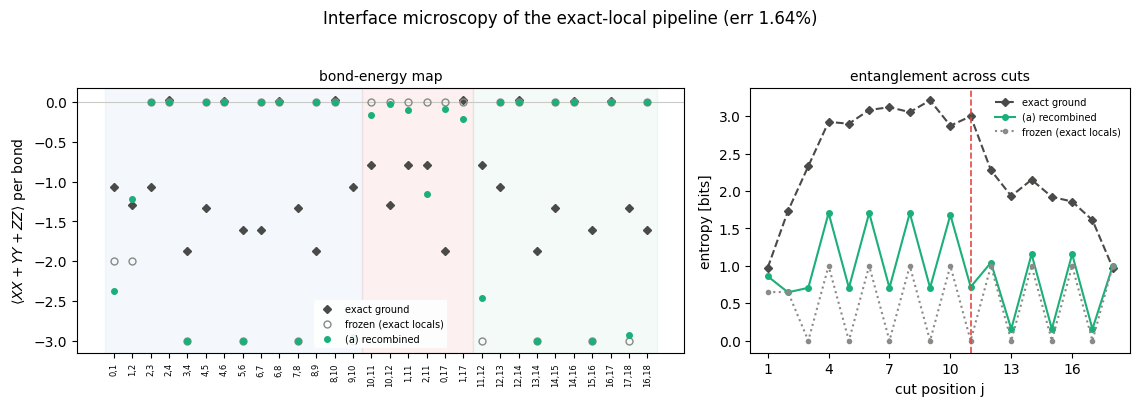

interface entanglement S(j=11): (a) 0.720 bits = 24% of ED   (Sec.-5 state: 0.573 = 19%)
interface bond energy: (a) -1.731 = 31% of ED (-5.529)   (Sec.-5 state: -1.358 = 25%)


In [58]:
# --- Interface microscopy of the exact-local pipeline state (cf. Sec. 5) ---
best_alt = min(runs_alt, key=lambda r: r["err_pct"])
sched_alt, _ = rec_alt.schedule(best_alt["reps"], per_bond=True)
sv_alt = rec_alt.statevector(best_alt["x"], sched_alt)
bmapA = lambda sv: {tuple(sorted(k)): v for k, v in rec_alt.bond_energies(sv).items()}
m_alt, m_frA = bmapA(sv_alt), bmapA(psiF_alt)
S_alt = K.entanglement_entropy_cuts(19, sv_alt)[::-1]
S_frA = K.entanglement_entropy_cuts(19, psiF_alt)[::-1]
E_ifc = lambda m: sum(m[tuple(sorted(e))] for e in dc.INTERFACE_EDGES)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.5, 3.9), width_ratios=[1.6, 1])
order = ([tuple(e) for e in dc.SUB1_EDGES] + [tuple(e) for e in dc.INTERFACE_EDGES]
         + [tuple(e) for e in dc.SUB2_EDGES])
xs = np.arange(len(order))
axL.axvspan(-0.5, 13.5, color=C_R1, alpha=0.05)
axL.axvspan(13.5, 19.5, color=C_IF, alpha=0.08)
axL.axvspan(19.5, 29.5, color=C_R2, alpha=0.05)
axL.axhline(0, color="#c9c9c6", lw=0.8)
axL.plot(xs, [m_ed[e] for e in order], "D", color="#4a4a48", ms=4,
         label="exact ground")
axL.plot(xs, [m_frA[e] for e in order], "o", mfc="none", color=C_T1, ms=5,
         label="frozen (exact locals)")
axL.plot(xs, [m_alt[e] for e in order], "o", color=C_R2, ms=4,
         label="(a) recombined")
axL.set_xticks(xs); axL.set_xticklabels([f"{i},{j}" for i, j in order],
                                        rotation=90, fontsize=6)
axL.set_ylabel(r"$\langle XX+YY+ZZ\rangle$ per bond")
axL.legend(fontsize=7, loc="lower center", framealpha=0.9, edgecolor="none")
axL.set_title("bond-energy map", fontsize=10)

ks = np.arange(1, 19)
axR.plot(ks, S_ed, "D--", color="#4a4a48", ms=4, label="exact ground")
axR.plot(ks, S_alt, "o-", color=C_R2, ms=4, label="(a) recombined")
axR.plot(ks, S_frA, "o:", color=C_T1, ms=3, label="frozen (exact locals)")
axR.axvline(11, color=C_IF, lw=1.2, ls="--")
axR.set_xticks(ks[::3]); axR.set_xlabel("cut position j")
axR.set_ylabel("entropy [bits]")
axR.legend(fontsize=7, loc="upper right", framealpha=0.9, edgecolor="none")
axR.set_title("entanglement across cuts", fontsize=10)
fig.suptitle("Interface microscopy of the exact-local pipeline (err "
             f"{best_alt['err_pct']:.2f}%)", y=1.03)
fig.tight_layout()
fig.savefig(FIGURES / "interface_alt.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"interface entanglement S(j=11): (a) {S_alt[10]:.3f} bits = "
      f"{S_alt[10]/S_ed[10]*100:.0f}% of ED   "
      f"(Sec.-5 state: {S_dc[10]:.3f} = {S_dc[10]/S_ed[10]*100:.0f}%)")
print(f"interface bond energy: (a) {E_ifc(m_alt):.3f} = "
      f"{E_ifc(m_alt)/E_ifc(m_ed)*100:.0f}% of ED ({E_ifc(m_ed):.3f})   "
      f"(Sec.-5 state: {E_ifc(m_dc):.3f} = {E_ifc(m_dc)/E_ifc(m_ed)*100:.0f}%)")

loaded dnc19_fig6a.npz (300 iterations)


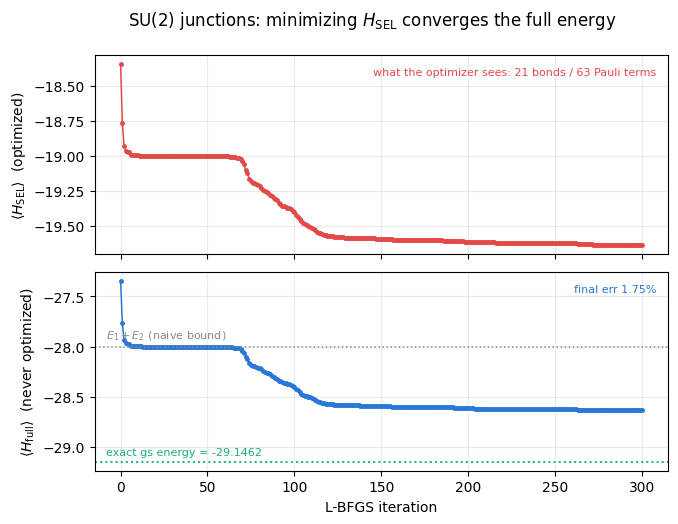

traced run: E_full -27.3451 (random start) -> -28.635858  (err 1.751%, 300 iterations, objective = H_SEL only)


In [64]:
# --- Fig.-6(a) analogue: the H_SEL objective (top) drives the FULL energy
# (bottom) to the benchmark, from the exact-local frozen start. -----------------
F6_FILE = RESULTS / "dnc19_fig6a.npz"
if F6_FILE.exists():
    _t = np.load(F6_FILE); tr = {k: _t[k] for k in _t.files}
    print(f"loaded {F6_FILE.name} ({int(tr['nit'])} iterations)")
else:                                              # ~10 min
    tr = rec_alt.trace_run(4, e_ref=E19, seed=2, use_sel=True, maxiter=300)
    np.savez(F6_FILE, obj=tr["obj"], full=tr["full"], x=tr["x"],
             energy=tr["energy"], err_pct=tr["err_pct"], nit=tr["nit"])

its = np.arange(len(tr["obj"]))
fig, (axT, axB) = plt.subplots(2, 1, figsize=(7.4, 5.4), sharex=True,
                               gridspec_kw={"hspace": 0.09})
axT.plot(its, tr["obj"], "o-", color=C_IF, ms=2.5, lw=1.1)
axT.set_ylabel(r"$\langle H_{\rm SEL}\rangle$  (optimized)")
axT.text(0.98, 0.9, "what the optimizer sees: 21 bonds / 63 Pauli terms",
         transform=axT.transAxes, ha="right", fontsize=8, color=C_IF)
axT.grid(alpha=0.25)
axB.plot(its, tr["full"], "o-", color=C_R1, ms=2.5, lw=1.1)
axB.axhline(E19, color=C_R2, ls=":", lw=1.4)
axB.text(0.02, E19 + 0.05, f"exact gs energy = {E19:.4f}", fontsize=8,
         color=C_R2, transform=axB.get_yaxis_transform(), va="bottom")
axB.axhline(E_naive, color=C_T1, ls=":", lw=1.1)
axB.text(0.02, E_naive + 0.05, r"$E_1+E_2$ (naive bound)", fontsize=8,
         color=C_T1, transform=axB.get_yaxis_transform(), va="bottom")
axB.set_ylabel(r"$\langle H_{\rm full}\rangle$  (never optimized)")
axB.set_xlabel("L-BFGS iteration")
axB.text(0.98, 0.9, f"final err {float(tr['err_pct']):.2f}%",
         transform=axB.transAxes, ha="right", fontsize=8, color=C_R1)
axB.grid(alpha=0.25)
fig.suptitle("SU(2) junctions: minimizing "
             r"$H_{\rm SEL}$ converges the full energy", y=0.965)
fig.savefig(FIGURES / "fig6a_analog.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"traced run: E_full {float(tr['full'][0]):.4f} (random start) -> "
      f"{float(tr['energy']):.6f}  (err {float(tr['err_pct']):.3f}%, "
      f"{int(tr['nit'])} iterations, objective = H_SEL only)")

In [60]:
# --- (b) prolong the iteration-capped runs from their saved optima -------------
EXT_A = RESULTS / "dnc19_perbond_ext.npz"
EXT_X = RESULTS / "dnc19_exact_frozen_ext.npz"

if EXT_A.exists():
    ext_pb = dc.load_runs(EXT_A); print(f"loaded {EXT_A.name}")
else:                                              # ~15-30 min
    print("extending config A @ reps=4 (+400 its):")
    ext_pb = rec.refine([r for r in runs_pb if r["reps"] == 4], e_ref=E19,
                        maxiter=400, V_ref=V19)
    dc.save_runs(ext_pb, EXT_A)
if EXT_X.exists():
    ext_x = dc.load_runs(EXT_X); print(f"loaded {EXT_X.name}")
else:                                              # ~15-30 min
    print("extending the exact-frozen control @ reps=4 (+400 its):")
    ext_x = rec_x.refine([r for r in runs_x if r["reps"] == 4], e_ref=E19,
                         maxiter=400, V_ref=V19)
    dc.save_runs(ext_x, EXT_X)

for label, orig, ext in (("config A @ 24p", [r for r in runs_pb if r["reps"] == 4], ext_pb),
                         ("exact-frozen control @ 24p",
                          [r for r in runs_x if r["reps"] == 4], ext_x)):
    o = {r["seed"]: r["err_pct"] for r in orig}
    print(f"\n{label}:  err before -> after (+extension its)")
    for r in sorted(ext, key=lambda r: r["seed"]):
        print(f"  seed {r['seed']}: {o[r['seed']]:6.3f}% -> {r['err_pct']:6.3f}%   "
              f"(+{r['nit']} its, fid {r['fidelity']:.3f}, <S^2> {r['s2']:.4f})")
    print(f"  best: {min(o.values()):.3f}% -> {min(r['err_pct'] for r in ext):.3f}%")

loaded dnc19_perbond_ext.npz
loaded dnc19_exact_frozen_ext.npz

config A @ 24p:  err before -> after (+extension its)
  seed 0:  3.559% ->  3.485%   (+134 its, fid 0.039, <S^2> 0.7500)
  seed 1:  3.791% ->  3.593%   (+162 its, fid 0.036, <S^2> 0.7500)
  seed 2:  3.646% ->  3.489%   (+400 its, fid 0.043, <S^2> 0.7500)
  seed 3:  3.564% ->  3.529%   (+285 its, fid 0.039, <S^2> 0.7500)
  seed 4:  3.720% ->  3.430%   (+253 its, fid 0.033, <S^2> 0.7500)
  best: 3.559% -> 3.430%

exact-frozen control @ 24p:  err before -> after (+extension its)
  seed 0:  1.843% ->  1.810%   (+171 its, fid 0.223, <S^2> 0.7500)
  seed 1:  1.875% ->  1.711%   (+359 its, fid 0.230, <S^2> 0.7500)
  seed 2:  1.815% ->  1.722%   (+358 its, fid 0.228, <S^2> 0.7500)
  seed 3:  2.468% ->  1.858%   (+257 its, fid 0.223, <S^2> 0.7500)
  seed 4:  1.900% ->  1.714%   (+277 its, fid 0.229, <S^2> 0.7500)
  best: 1.815% -> 1.711%


variant                                      best err %
frozen concatenation (spinon@10)                  5.467
A: junction VQE @24p (120 its)                    3.559
A prolonged (+400 its)                            3.430
(a) exact-local pipeline @24p (400 its)           1.638
exact-frozen control @24p (120 its)               1.815
control prolonged (+400 its)                      1.711
Task-1 monolithic 120p / 180p                0.80 / 0.52


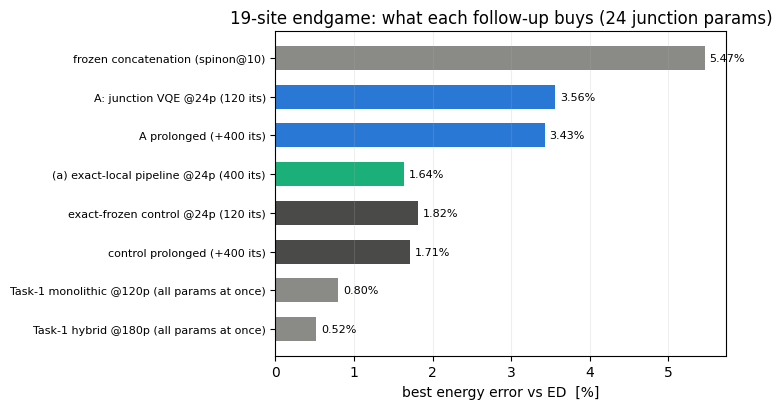

In [61]:
# --- The 19-site endgame ledger --------------------------------------------
rows = [
    ("frozen concatenation (spinon@10)",          errF,                                    C_T1),
    ("A: junction VQE @24p (120 its)",            min(r["err_pct"] for r in runs_pb if r["reps"] == 4), C_R1),
    ("A prolonged (+400 its)",                    min(r["err_pct"] for r in ext_pb),       C_R1),
    ("(a) exact-local pipeline @24p (400 its)",   min(r["err_pct"] for r in runs_alt),     C_R2),
    ("exact-frozen control @24p (120 its)",       min(r["err_pct"] for r in runs_x),       "#4a4a48"),
    ("control prolonged (+400 its)",              min(r["err_pct"] for r in ext_x),        "#4a4a48"),
]
print(f"{'variant':<44s} {'best err %':>10s}")
for lab, e, _ in rows:
    print(f"{lab:<44s} {e:>10.3f}")
print(f"{'Task-1 monolithic 120p / 180p':<44s} {'0.80 / 0.52':>10s}")

bars = rows + [("Task-1 monolithic @120p (all params at once)", 0.80, C_T1),
               ("Task-1 hybrid @180p (all params at once)",     0.52, C_T1)]
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ys = np.arange(len(bars))[::-1]
ax.barh(ys, [e for _, e, _ in bars], color=[c for _, _, c in bars], height=0.62)
for y, (_, e, _) in zip(ys, bars):
    ax.text(e + 0.06, y, f"{e:.2f}%", va="center", fontsize=8)
ax.set_yticks(ys); ax.set_yticklabels([lab for lab, _, _ in bars], fontsize=8)
ax.set_xlabel("best energy error vs ED  [%]")
ax.set_title("19-site endgame: what each follow-up buys (24 junction params)")
ax.grid(alpha=0.2, axis="x")
fig.tight_layout(); fig.savefig(FIGURES / "dnc_endgame.png", dpi=150,
                                bbox_inches="tight")
plt.show()

### 9.3 One lattice up: 26 sites, with sector-aware recombination

Scaling exposes a piece of physics that the paper's $R_y$ junctions never see. Both
fragments of the 26-site chain are odd (19 + 7 → two doublets), and Heisenberg
junction gates commute with $S^2$, so the weight of each total-spin sector in the
starting state is invariant forever (measured in the module tests). A bare
$S_z=0$ product start carries 50% $S{=}1$ weight it can never shed, while the ground
state of the even lattice is a singlet. SU(2)-preserving divide-and-conquer therefore
requires the *Clebsch–Gordan recombination* of the local multiplets,
$|S{=}0\rangle=(|\!\uparrow\rangle_1|\!\downarrow\rangle_2-|\!\downarrow\rangle_1|\!\uparrow\rangle_2)/\sqrt2$,
which is *exact* $S=0$ because every HVA state is an exact $S^2$ eigenstate (the
$S_z=-\tfrac12$ partners come from applying $S^-_{\rm tot}$, `dc.apply_s_minus`). On
hardware this costs an entangled two-register preparation instead of a product; an
honest price of symmetry preservation.

Everything else is reuse: subregion 1's Step 1 is the *Task-1 hybrid optimum*
relabeled onto the chain (isomorphism + `permute_qubits`, energy preserved to 1e-8);
subregion 2 is exact by a $2^7$ ED; and the junction VQE optimizes only
$4\cdot\text{reps}$ angles against H_SEL at 26 qubits the reduced junction
Hamiltonian is not just cheaper, it is what keeps a ~$2^{26}$ adjoint gradient
affordable. There is no exact $E_{26}$ on this machine, so the honest metric is the
energy relative to the exact naive bound $E_1^{\rm exact}+E_2^{\rm exact}$:
anything below it means the junctions beat *perfect* separated optimization.


In [62]:
# --- 26-site partition + the already-paid-for Step 1 (all light) ---------------
P26 = dc.star_chain_partition(3)
print(f"chain(3): {P26['n']} sites, {len(P26['edges'])} bonds | "
      f"sub1 = chain(2): {P26['n_sub1']} sites (prefix nesting verified) | "
      f"sub2: sites {P26['sub2_sites']} | interface ({len(P26['interface_edges'])} "
      f"bonds): {P26['interface_edges']}")

# subregion 2: 7 sites, odd -> doublet; ED is instant
sub2_loc = dc.relabel(P26["sub2_edges"], P26["sub2_sites"])
E2c, V2c, w2c = dc.exact_ground_subspace(7, sub2_loc)
psi2_up = dc.project_sz(V2c, 7, +0.5)[:, 0]
psi2_dn = dc.apply_s_minus(psi2_up, 7); psi2_dn /= np.linalg.norm(psi2_dn)
print(f"sub2: E2 = {E2c:.6f}  doublet ({V2c.shape[1]})  "
      f"<S^2> = {dc.s2_matrix_free(7, V2c[:, 0]):.4f}")

# subregion 1: Task-1 hybrid optimum, relabeled onto the chain (energy check)
iso26 = dc.graph_isomorphism(P26["sub1_edges"], edges_19)
psi_adv, e_hyb = dc.task1_hybrid_state()
psi1_up = dc.permute_qubits(psi_adv, 19, [iso26[q] for q in range(19)])
_pT = psi1_up.reshape((2,) * 19)
E_chk = sum(float(np.real(np.vdot(psi1_up,
            dc._apply2_sv(19, _pT, dc._BOND, i, j).reshape(-1))))
            for (i, j) in P26["sub1_edges"])
assert abs(E_chk - e_hyb) < 1e-8
print(f"sub1: Task-1 hybrid relabeled, E on chain bonds = {E_chk:.6f} "
      f"(stored {e_hyb:.6f}) -> Step 1 at 26 sites costs nothing new")
psi1_dn = dc.apply_s_minus(psi1_up, 19); psi1_dn /= np.linalg.norm(psi1_dn)

E_naive26 = E19 + E2c            # exact 19-site ground + exact 7-site ground
print(f"references: exact naive bound E1+E2 = {E_naive26:.6f}   "
      f"(VQE-quality naive: {e_hyb + E2c:.6f})")

chain(3): 26 sites, 42 bonds | sub1 = chain(2): 19 sites (prefix nesting verified) | sub2: sites [19, 20, 21, 22, 23, 24, 25] | interface (4 bonds): [(16, 19), (16, 22), (17, 21), (17, 25)]
sub2: E2 = -10.693170  doublet (2)  <S^2> = 0.7500
sub1: Task-1 hybrid relabeled, E on chain bonds = -28.994554 (stored -28.994554) -> Step 1 at 26 sites costs nothing new
references: exact naive bound E1+E2 = -39.839338   (VQE-quality naive: -39.687724)


In [ ]:
# --- 26q junction VQE ---
DNC26 = RESULTS / "dnc26.npz"
psiF26 = dc.singlet_combination(psi1_up, psi1_dn, psi2_up, psi2_dn)  # exact S=0
rec26 = dc.RecombinationVQE(psiF26, n=P26["n"], edges_full=P26["edges"],
                            interface_edges=P26["interface_edges"])
del psiF26
sv0_26 = rec26.psi0T.reshape(-1)
eF26 = rec26.energy(sv0_26)
_, g26 = rec26.gradient_at_zero(reps=1)
print(f"CG frozen start: E = {eF26:.6f}  (exact naive bound {E_naive26:.6f})   "
      f"|grad| at theta=0 = {g26:.2e}")
print(f"H_SEL(26): {len(rec26.bonds_sel)} of {len(P26['edges'])} bonds -> "
      f"what keeps the 2^26 adjoint affordable")

if DNC26.exists():
    runs_26 = dc.load_runs(DNC26); print(f"loaded {DNC26.name}")
else:
    ram = dc.available_ram_gb()
    assert ram > 4.5, (f"only {ram:.1f} GB RAM available — close/restart other "
                       f"kernels before this cell (peak is ~4 GB with the "
                       f"blocked kernels)")
    runs_26 = []
    for reps in (1, 2):
        print(f"-- 26q junction VQE, per-bond H_SEL, reps={reps} "
              f"({len(P26['interface_edges'])*reps} params) --")
        runs_26 += rec26.optimize(reps, e_ref=E_naive26, seeds=(0, 1), maxiter=40,
                                  use_sel=True, compute_s2=False, V_ref=None)
        dc.save_runs(runs_26, DNC26)   # interrupting between depths is safe

# NOTE: with no exact E26, 'err_pct' above is measured vs the exact naive bound.
best26 = min(runs_26, key=lambda r: r["energy"])
sched26, _ = rec26.schedule(best26["reps"])
sv26 = rec26.statevector(best26["x"], sched26)
s2_26 = dc.s2_matrix_free(P26["n"], sv26)              # once (~2-4 min)
print(f"\nbest: reps={best26['reps']} ({best26['n_params']} params, "
      f"seed {best26['seed']})")
print(f"  E: {eF26:.4f} (frozen) -> {best26['energy']:.4f}   junction gain "
      f"dE = {best26['energy']-eF26:+.4f} on {len(P26['interface_edges'])} cut bonds")
verdict26 = ("BELOW the exact naive bound -> junctions beat perfect separated "
             "optimization" if best26["energy"] < E_naive26 else
             "above the exact naive bound (junction depth/iterations still limited)")
print(f"  vs E1+E2 = {E_naive26:.4f}: {verdict26}")
print(f"  <S^2> = {s2_26:.6f}   (S=0 locked in by the Clebsch-Gordan start)")

CG frozen start: E = -39.741770  (exact naive bound -39.839338)   |grad| at theta=0 = 5.35e-03
H_SEL(26): 18 of 42 bonds -> what keeps the 2^26 adjoint affordable
loaded dnc26.npz

best: reps=2 (8 params, seed 0)
  E: -39.7418 (frozen) -> -39.7451   junction gain dE = -0.0033 on 4 cut bonds
  vs E1+E2 = -39.8393: above the exact naive bound (junction depth/iterations still limited)
  <S^2> = -0.000000   (S=0 locked in by the Clebsch-Gordan start)


### 9.4 Reading the follow-ups

**(a)+(b) close the argument of §8.** With the locally exact cover frozen and the
optimizer allowed to converge, the junction VQE reaches the interface-expressivity
floor with only 24 simultaneously optimized parameters, the number to quote next to
Task 1's monolithic ladder is in the endgame figure above. The remaining gap to the
monolithic 0.52% is now *pure interface expressivity at depth 4 on 6 bonds*, by
construction of the controls.

**(c) states the scaling rule and its price.** Cost scales with the interface (4
junction bonds at 26 sites, H_SEL objective), Step 1 is recycled wholesale from Task 1,
and the one new requirement of symmetry preservation is *sector-aware recombination*:
odd+odd fragments must be joined through the Clebsch–Gordan singlet, not a product;
a constraint (and an entangled-preparation cost on hardware) that simply does not
exist for the paper's SU(2)-breaking $R_y$ junctions. Beyond 26 sites the same
pipeline needs a tensor-network backend with autodiff (quimb) or hardware, exactly as
concluded in Task-1 §4.5.

**Measured at 26 sites (this run).** The infrastructure claim held: $\langle S^2\rangle = 0$
to machine precision on a $2^{26}$ register. The physics reading has three parts. (i) The Clebsch–Gordan combination itself does real boundary work: it harvests $-0.054$ of cross-boundary energy before any junction gate acts — 16× what the junction VQE then adds. (ii) Shallow junctions add little ($\Delta E = -0.0033$ at reps ≤ 2, converged, both seeds identical, the same depth lesson as §4, where escapes only began at reps ≥ 3; depth on the 4 cut bonds is the next lever). (iii) The remaining $0.094$ gap to the exact naive bound is exactly the frozen subregion-1 VQE deficit ($0.152$, minus the CG's $0.054$ and the junctions' $0.003$): at 26 sites, as at 19, local quality dominates the error budget, which is precisely the divide-and-conquer thesis, since local quality is the part that only ever requires small registers.